# Extended Matching in Supply Chain Analysis


--- *Analysis originally redone on 23rd March 2026* ---

## Introduction

Three scenarios are presented to illustrate the use of extended matching in supply chain. The scenarios are:
1. **Siloed SHUs**: This scenario involves a supply chain where each stock holding unit (SHU) operates independently, leading to inefficiencies and lack of coordination.
2. **SHU Network**: In this scenario, SHUs are interconnected, allowing for better resource sharing and coordination among different units.
3. **SHU Network with Penalisation of Transportation**: This scenario builds on the SHU network but introduces penalties for transportation, which can affect decision-making and resource allocation.

All scenarios take into account three future days of sickle cell disorder (SCD) patient demand, but only the latter two scenarios consider the reservation and transportation of blood units between SHUs.
Shelf life is set to 23 days (zero-indexed), with a warm-up period of 84 days and an additional time horizon of 42 days, resulting in a total simulation period of 126 days. There are 100 replications for each scenario.

The number of donations, number of patient appointments, and number of RBC units per appointment are now all stochastic. The former two are modeled using Poisson distributions, while the latter is modeled using a discrete distribution based on historical data.
Weekend and weekday patterns are also considered for both donations and appointments.

Movement of units between locations is allowed in the SHU network scenarios, with transportation times based on real-world data from NHSBT. These movements are restricted to happen just-in-time for patient appointments (i.e., units are moved so that they arrive on the day of the appointment's deadline).
Transport between SHUs are heterogeneous, with different travel times (and costs) depending on the origin and destination SHUs, as well as the day of the week. It is also worth noting that these are not necessarily symmetric.
R<sub>0</sub> units are barred from being transported between SHUs for the purpose of rebalancing stock levels. They can be transported to meet a future patient appointment, however.


## Experiments

Experiments on the following:
- L01/E01: Siloed SHUs with a few days of future SCD demand anticipation. No movement of units. This would be with both Limited and Extended matching. Limited matching rule would be the best approximation to current practice. So Extended matching is the first next step. Although comparison is useful, it is not a main point of this work.
- E02: Networked SHUs, which allows for unpenalised movement of units between SHUs to meet anticipated SCD demand. Would only be with Extended matching. Useful as it shows where units want to go to meet patient need & minimise xA.
- E03: Network which penalises movement of units to meet anticipated SCD demand based on distance between the SHUs.


## Questions

We look at different scenarios of E03 by varying the weight of the transportation penalties. We want to see the trade-off in the number of moved units to xA.
This is because the moved units are being moved ‘for free’ on the routes that are already running. However, more units moved means more effort needed to find and retrieve the specific units in storage.

Choose a setting of E03, and look at how much is being exchanged between different SHUs, and try and deduce if this could be avoided by anticipating supply and shipping directly to the SHU.
Or otherwise adapting the distribution approache(s).
Does this meaningfully increase efficiency or just change where the ‘work’ of sorting/finding/retrieving units happens?
How old are the units when they are moved: if young, they could have been distributed better in the first place.
How often are units moved? We would want to avoid redundant work from moving units multiple times.

Allow decision on whether to move units faster by courier, thereby accruing transportation costs OR use ‘slower’ routes and have higher xA instead.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm.notebook
from tqdm.notebook import trange

%load_ext autoreload
%autoreload 2

%aimport scratch.convenience_functions

cf = scratch.convenience_functions

sns.set_theme(style="white", context="notebook", font_scale=1.5, font="Nimbus Roman")

## Results Filenames

In [2]:
limited_siloed_shus = 'out/experiments/exp4/20260325/1156/exp4-siloed-L0112-27_output.tsv'
siloed_shus = 'out/experiments/exp4/20260325/1145/exp4-siloed-E0112-16_output.tsv'
shus_zero_transportation = 'out/experiments/exp4/20260325/1154/exp4-network-no_cost-E0212-47_output.tsv'
shus_transportation_penalty = 'out/experiments/exp4/20260325/1143/exp4-network-penalisation-E0312-31_output.tsv'

all_results = dict(limited_siloed_shus=limited_siloed_shus,
                   siloed_shus=siloed_shus,
                   shus_zero_transportation=shus_zero_transportation,
                   shus_transportation_penalty=shus_transportation_penalty,)

In [3]:
transport_weight_0_00 = shus_zero_transportation
transport_weight_1_00 = shus_transportation_penalty
transport_weight_inf = siloed_shus

transport_weight_0_01 = 'out/experiments/exp4/20260325/1142/transport_weight-0.0112-33_output.tsv'
transport_weight_0_02 = 'out/experiments/exp4/20260325/1148/transport_weight-0.0212-37_output.tsv'
transport_weight_0_03 = 'out/experiments/exp4/20260325/1146/transport_weight-0.0312-29_output.tsv'
transport_weight_0_04 = 'out/experiments/exp4/20260325/1152/transport_weight-0.0412-51_output.tsv'
transport_weight_0_05 = 'out/experiments/exp4/20260325/1149/transport_weight-0.0512-45_output.tsv'
transport_weight_0_07 = 'out/experiments/exp4/20260325/1144/transport_weight-0.0712-39_output.tsv'
transport_weight_0_10 = 'out/experiments/exp4/20260325/1153/transport_weight-0.1012-39_output.tsv'
transport_weight_0_15 = 'out/experiments/exp4/20260325/1150/transport_weight-0.1512-56_output.tsv'
transport_weight_0_20 = 'out/experiments/exp4/20260325/1147/transport_weight-0.2012-52_output.tsv'
transport_weight_0_35 = 'out/experiments/exp4/20260325/1151/transport_weight-0.3512-57_output.tsv'
transport_weight_0_50 = 'out/experiments/exp4/20260325/1155/transport_weight-0.5012-42_output.tsv'


all_transport_weight_results = dict(transport_weight_0_00=transport_weight_0_00,
                                     transport_weight_0_01=transport_weight_0_01,
                                     transport_weight_0_02=transport_weight_0_02,
                                     transport_weight_0_03=transport_weight_0_03,
                                     transport_weight_0_04=transport_weight_0_04,
                                     transport_weight_0_05=transport_weight_0_05,
                                     transport_weight_0_07=transport_weight_0_07,
                                     transport_weight_0_10=transport_weight_0_10,
                                     transport_weight_0_15=transport_weight_0_15,
                                     transport_weight_0_20=transport_weight_0_20,
                                     transport_weight_0_35=transport_weight_0_35,
                                     transport_weight_0_50=transport_weight_0_50,
                                     transport_weight_1_00=transport_weight_1_00,
                                     transport_weight_inf=transport_weight_inf)

## Setup

In [4]:
major_types_to_plot = ['O-', 'O+', 'B-', 'B+', 'A-', 'A+', 'AB-', 'AB+']
warmup_period = 7*6*2
time_horizon = 7*6*3
days_range = np.arange(0, time_horizon) + 1
list_of_locations = ['SHU_Colindale', 'SHU_Filton', 'SHU_Manchester', 'SHU_Tooting',
       'SHU_Basildon', 'SHU_Cambridge', 'SHU_Plymouth', 'SHU_Southampton',
       'SHU_Birmingham', 'SHU_Oxford', 'SHU_Barnsley', 'SHU_Lancaster',
       'SHU_Liverpool', 'SHU_Newcastle']
locs_sans_shu = [location[4:] for location in list_of_locations]
list_of_location_ids = [11, 13, 17, 19,
                        23, 29, 31, 37,
                        41, 43, 47, 53,
                        59, 61]
list_of_locations = np.array(list_of_locations)
id_shu_dict = dict(zip(list_of_location_ids, list_of_locations))
move_reasons=dict(rebalancing=0, SCD=3,)
indices_scd_locations = [0, 1, 2, 3, 4, 8, 9, 10,]
indices_non_scd_locations = [5, 6, 7, 11, 12, 13]
order_of_locations = indices_scd_locations + indices_non_scd_locations
order_of_locations_by_scd_demand = [0, 2, 1, 3, 4, 10, 8, 9, 13, 12, 7, 5, 6, 11]
travel_costs = pd.read_csv('scratch/data_files/location_courier_costs.tsv', sep='\t', index_col=0)
travel_costs_mask = pd.read_csv('scratch/data_files/location_needs_courier.tsv', sep='\t', index_col=0)
courier_costs = travel_costs.where(travel_costs_mask).fillna(
    0).loc[locs_sans_shu, locs_sans_shu]
courier_costs_shuified = courier_costs.rename(index=dict(zip(locs_sans_shu, list_of_locations)),
                                              columns=dict(zip(locs_sans_shu, list_of_locations)))
rule_keys = ['L01', 'E01', 'E02', 'E03']
duffy_types_to_plot = ['Fya-', 'Fyb-',]
days_range_start = warmup_period + 1
days_range_end = time_horizon + 1
minor_types_to_plot = ['R0', 'Fya-', 'Fyb-', 'TOTAL']
shelf_life = 23
age_range = np.arange(0, shelf_life + 1)
scenario_labels = dict(limited_siloed_shus='L01: Limited Siloed SHUs',
                       siloed_shus='E01: Siloed SHUs',
                       shus_zero_transportation='E02: SHUs with Zero Transportation',
                       shus_transportation_penalty='E03: SHUs with Transportation Penalty')
scenario_labels_compact = dict(limited_siloed_shus='L01',
                               siloed_shus='E01',
                               shus_zero_transportation='E02',
                               shus_transportation_penalty='E03')
transport_weight_labels = dict(transport_weight_0_00='0.00',
                               transport_weight_0_01='0.01',
                               transport_weight_0_02='0.02',
                               transport_weight_0_03='0.03',
                               transport_weight_0_04='0.04',
                               transport_weight_0_05='0.05',
                               transport_weight_0_07='0.07',
                               transport_weight_0_10='0.10',
                               transport_weight_0_15='0.15',
                               transport_weight_0_20='0.20',
                               transport_weight_0_35='0.35',
                               transport_weight_0_50='0.50',
                               transport_weight_1_00='1.00',
                            #    transport_weight_inf='∞',)
                               transport_weight_inf='N/A',)


### Is Recompilation of Moves Matrices Needed?
The compilation of moves matrices can be time-consuming, especially if there are many scenarios and replications. If the matrices have already been compiled and saved to disk, it may not be necessary to recompile them every time the notebook is run. Setting the `compile_moves_matrices` flag to `False` allows you to skip the compilation step and load the existing matrices instead, which can save time during analysis. If you want to recompile the matrices (for example, if you have made changes to the underlying data or the compilation process), you can set this flag to `True`.

In [5]:
compile_moves_matrices = False

## Objectives

In [6]:
obj_stats = cf.objectives_stats_table(all_results)
obj_stats

,limited_siloed_shus,siloed_shus,shus_zero_transportation,shus_transportation_penalty
alloimmunisations,11.844 ± 0.030,1.431 ± 0.010,0.583 ± 0.006,1.425 ± 0.010
scd_shortages,0.190 ± 0.112,0.220 ± 0.114,0.000 ± 0.000,0.060 ± 0.060
expiries,0.000 ± 0.000,0.000 ± 0.000,0.030 ± 0.022,0.000 ± 0.000
all_shortages,0.190 ± 0.112,0.220 ± 0.114,0.000 ± 0.000,0.690 ± 0.606
moves,2526.090 ± 59.376,2529.620 ± 55.523,20835.780 ± 133.983,3458.160 ± 91.019
scd_moves,0.000 ± 0.000,0.000 ± 0.000,16876.240 ± 53.598,319.360 ± 6.586
other_moves,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
O_neg_level,0.152 ± 0.000,0.137 ± 0.000,0.141 ± 0.000,0.137 ± 0.000
O_pos_level,0.352 ± 0.000,0.355 ± 0.000,0.356 ± 0.000,0.355 ± 0.000
O_level,0.505 ± 0.000,0.492 ± 0.000,0.497 ± 0.000,0.493 ± 0.000


In [7]:
df_ltx = obj_stats.fillna('').astype(str).map(lambda s: '$' + s.replace('±', r'\pm') + '$')
df_ltx.columns = [str(c).replace('_', ' ') for c in df_ltx.columns]
df_ltx.index = [str(i).replace('_', ' ') for i in df_ltx.index]
if df_ltx.index.name is not None:
    df_ltx.index.name = str(df_ltx.index.name).replace('_', ' ')
if df_ltx.columns.name is not None:
    df_ltx.columns.name = str(df_ltx.columns.name).replace('_', ' ')
print(df_ltx.to_latex(escape=False))

\begin{tabular}{lllll}
\toprule
 & limited siloed shus & siloed shus & shus zero transportation & shus transportation penalty \\
\midrule
alloimmunisations & $11.844 \pm 0.030$ & $1.431 \pm 0.010$ & $0.583 \pm 0.006$ & $1.425 \pm 0.010$ \\
scd shortages & $0.190 \pm 0.112$ & $0.220 \pm 0.114$ & $0.000 \pm 0.000$ & $0.060 \pm 0.060$ \\
expiries & $0.000 \pm 0.000$ & $0.000 \pm 0.000$ & $0.030 \pm 0.022$ & $0.000 \pm 0.000$ \\
all shortages & $0.190 \pm 0.112$ & $0.220 \pm 0.114$ & $0.000 \pm 0.000$ & $0.690 \pm 0.606$ \\
moves & $2526.090 \pm 59.376$ & $2529.620 \pm 55.523$ & $20835.780 \pm 133.983$ & $3458.160 \pm 91.019$ \\
scd moves & $0.000 \pm 0.000$ & $0.000 \pm 0.000$ & $16876.240 \pm 53.598$ & $319.360 \pm 6.586$ \\
other moves & $0.000 \pm 0.000$ & $0.000 \pm 0.000$ & $0.000 \pm 0.000$ & $0.000 \pm 0.000$ \\
O neg level & $0.152 \pm 0.000$ & $0.137 \pm 0.000$ & $0.141 \pm 0.000$ & $0.137 \pm 0.000$ \\
O pos level & $0.352 \pm 0.000$ & $0.355 \pm 0.000$ & $0.356 \pm 0.000$ & $0.

## Stock Levels

In [8]:
print('Skipping stacked stock levels graph for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for key, value in all_results.items():
#     cf.stacked_stock_levels_graph(value, major_types_to_plot, demarcate_warmup=True,
#                                   raw_data=True, warmup_period=warmup_period,
#                                   figsize=(7, 4), dpi=150, title=scenario_labels[key],
#     )

Skipping stacked stock levels graph for all base scenarios...
Uncomment the following code block to plot if desired.



In [9]:
print('Skipping stacked stock levels graph by location for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for key, value in all_results.items():
#     cf.stacked_stock_levels_locations_graph(value, major_types_to_plot, 
#                                           list_of_locations, (5, 3),
#                                           phen_labels=major_types_to_plot,
#                                           loc_labels=list_of_locations,
#                                           warmup_period=warmup_period,
#                                           raw_data=True, days_range=days_range,
#                                           demarcate_warmup=False, figsize=(15, 18),
#                                           title=scenario_labels[key], y_lim=10_000,
#     )

Skipping stacked stock levels graph by location for all base scenarios...
Uncomment the following code block to plot if desired.



In [10]:
print('Skipping stacked stock levels graph by location for R0 for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for key, value in all_results.items():
#     cf.stacked_stock_levels_locations_graph(value, ['R0',], 
#                                           list_of_locations, (5, 3),
#                                           phen_labels=['R0'],
#                                           loc_labels=list_of_locations,
#                                           warmup_period=warmup_period,
#                                           raw_data=True, days_range=days_range,
#                                           demarcate_warmup=False, figsize=(16, 18),
#                                           title=scenario_labels[key], y_lim=750,
#     )

Skipping stacked stock levels graph by location for R0 for all base scenarios...
Uncomment the following code block to plot if desired.



## Moves & Transportation

### Compiling Move Matrices

In [11]:
if compile_moves_matrices:
    cf.compile_moves_matrix(list(all_results.values()),
                            id_shu_dict,
                            warm_up=warmup_period, move_reasons=move_reasons,
                            dest_col=9, date_moved_col=6, pat_grp_col=8, origin_col=3,)
else:
    print('Skipping compilation of moves matrix for all base scenarios, as it has already been compiled and saved to disk. Set `compile_moves_matrices` to True to recompile if desired.\n')

Skipping compilation of moves matrix for all base scenarios, as it has already been compiled and saved to disk. Set `compile_moves_matrices` to True to recompile if desired.



In [12]:
if compile_moves_matrices:
    cf.compile_moves_matrix([result for result in all_transport_weight_results.values() if result not in list(all_results.values())],
                            id_shu_dict,
                            warm_up=warmup_period, move_reasons=move_reasons,
                            dest_col=9, date_moved_col=6, pat_grp_col=8, origin_col=3,)
else:
    print('Skipping compilation of moves matrix for transport weight scenarios, as they have already been compiled and saved to disk. Set `compile_moves_matrices` to True to recompile if desired.\n')

Skipping compilation of moves matrix for transport weight scenarios, as they have already been compiled and saved to disk. Set `compile_moves_matrices` to True to recompile if desired.



### Topline Movement Statistics

In [13]:
limited_siloed_shus_moves_df = pd.read_csv(limited_siloed_shus.replace('output.tsv', 'compiled_moves_SCD.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in Limited Siloed SHUs for SCD: {limited_siloed_shus_moves_df.sum().sum()}')
siloed_shus_moves_df = pd.read_csv(siloed_shus.replace('output.tsv', 'compiled_moves_SCD.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in Siloed SHUs for SCD: {siloed_shus_moves_df.sum().sum()}')
shus_zero_transportation_moves_df = pd.read_csv(shus_zero_transportation.replace('output.tsv', 'compiled_moves_SCD.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in SHUs Zero Transportation for SCD: {shus_zero_transportation_moves_df.sum().sum()}')
shus_transportation_penalty_moves_df = pd.read_csv(shus_transportation_penalty.replace('output.tsv', 'compiled_moves_SCD.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in SHUs Transportation Penalty for SCD: {shus_transportation_penalty_moves_df.sum().sum()}')

Number of units moved in Limited Siloed SHUs for SCD: 0.0
Number of units moved in Siloed SHUs for SCD: 0.0
Number of units moved in SHUs Zero Transportation for SCD: 16876.24
Number of units moved in SHUs Transportation Penalty for SCD: 319.35999999999996


In [14]:
limited_siloed_shus_moves_df = pd.read_csv(limited_siloed_shus.replace('output.tsv', 'compiled_moves_rebalancing.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in Limited Siloed SHUs for rebalancing: {limited_siloed_shus_moves_df.sum().sum()}')
siloed_shus_moves_df = pd.read_csv(siloed_shus.replace('output.tsv', 'compiled_moves_rebalancing.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in Siloed SHUs for rebalancing: {siloed_shus_moves_df.sum().sum()}')
shus_zero_transportation_moves_df = pd.read_csv(shus_zero_transportation.replace('output.tsv', 'compiled_moves_rebalancing.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in SHUs Zero Transportation for rebalancing: {shus_zero_transportation_moves_df.sum().sum()}')
shus_transportation_penalty_moves_df = pd.read_csv(shus_transportation_penalty.replace('output.tsv', 'compiled_moves_rebalancing.tsv'), sep='\t', index_col=0)
print(f'Number of units moved in SHUs Transportation Penalty for rebalancing: {shus_transportation_penalty_moves_df.sum().sum()}')

Number of units moved in Limited Siloed SHUs for rebalancing: 2526.09
Number of units moved in Siloed SHUs for rebalancing: 2529.62
Number of units moved in SHUs Zero Transportation for rebalancing: 3959.54
Number of units moved in SHUs Transportation Penalty for rebalancing: 3138.7999999999997


### Move Matrices

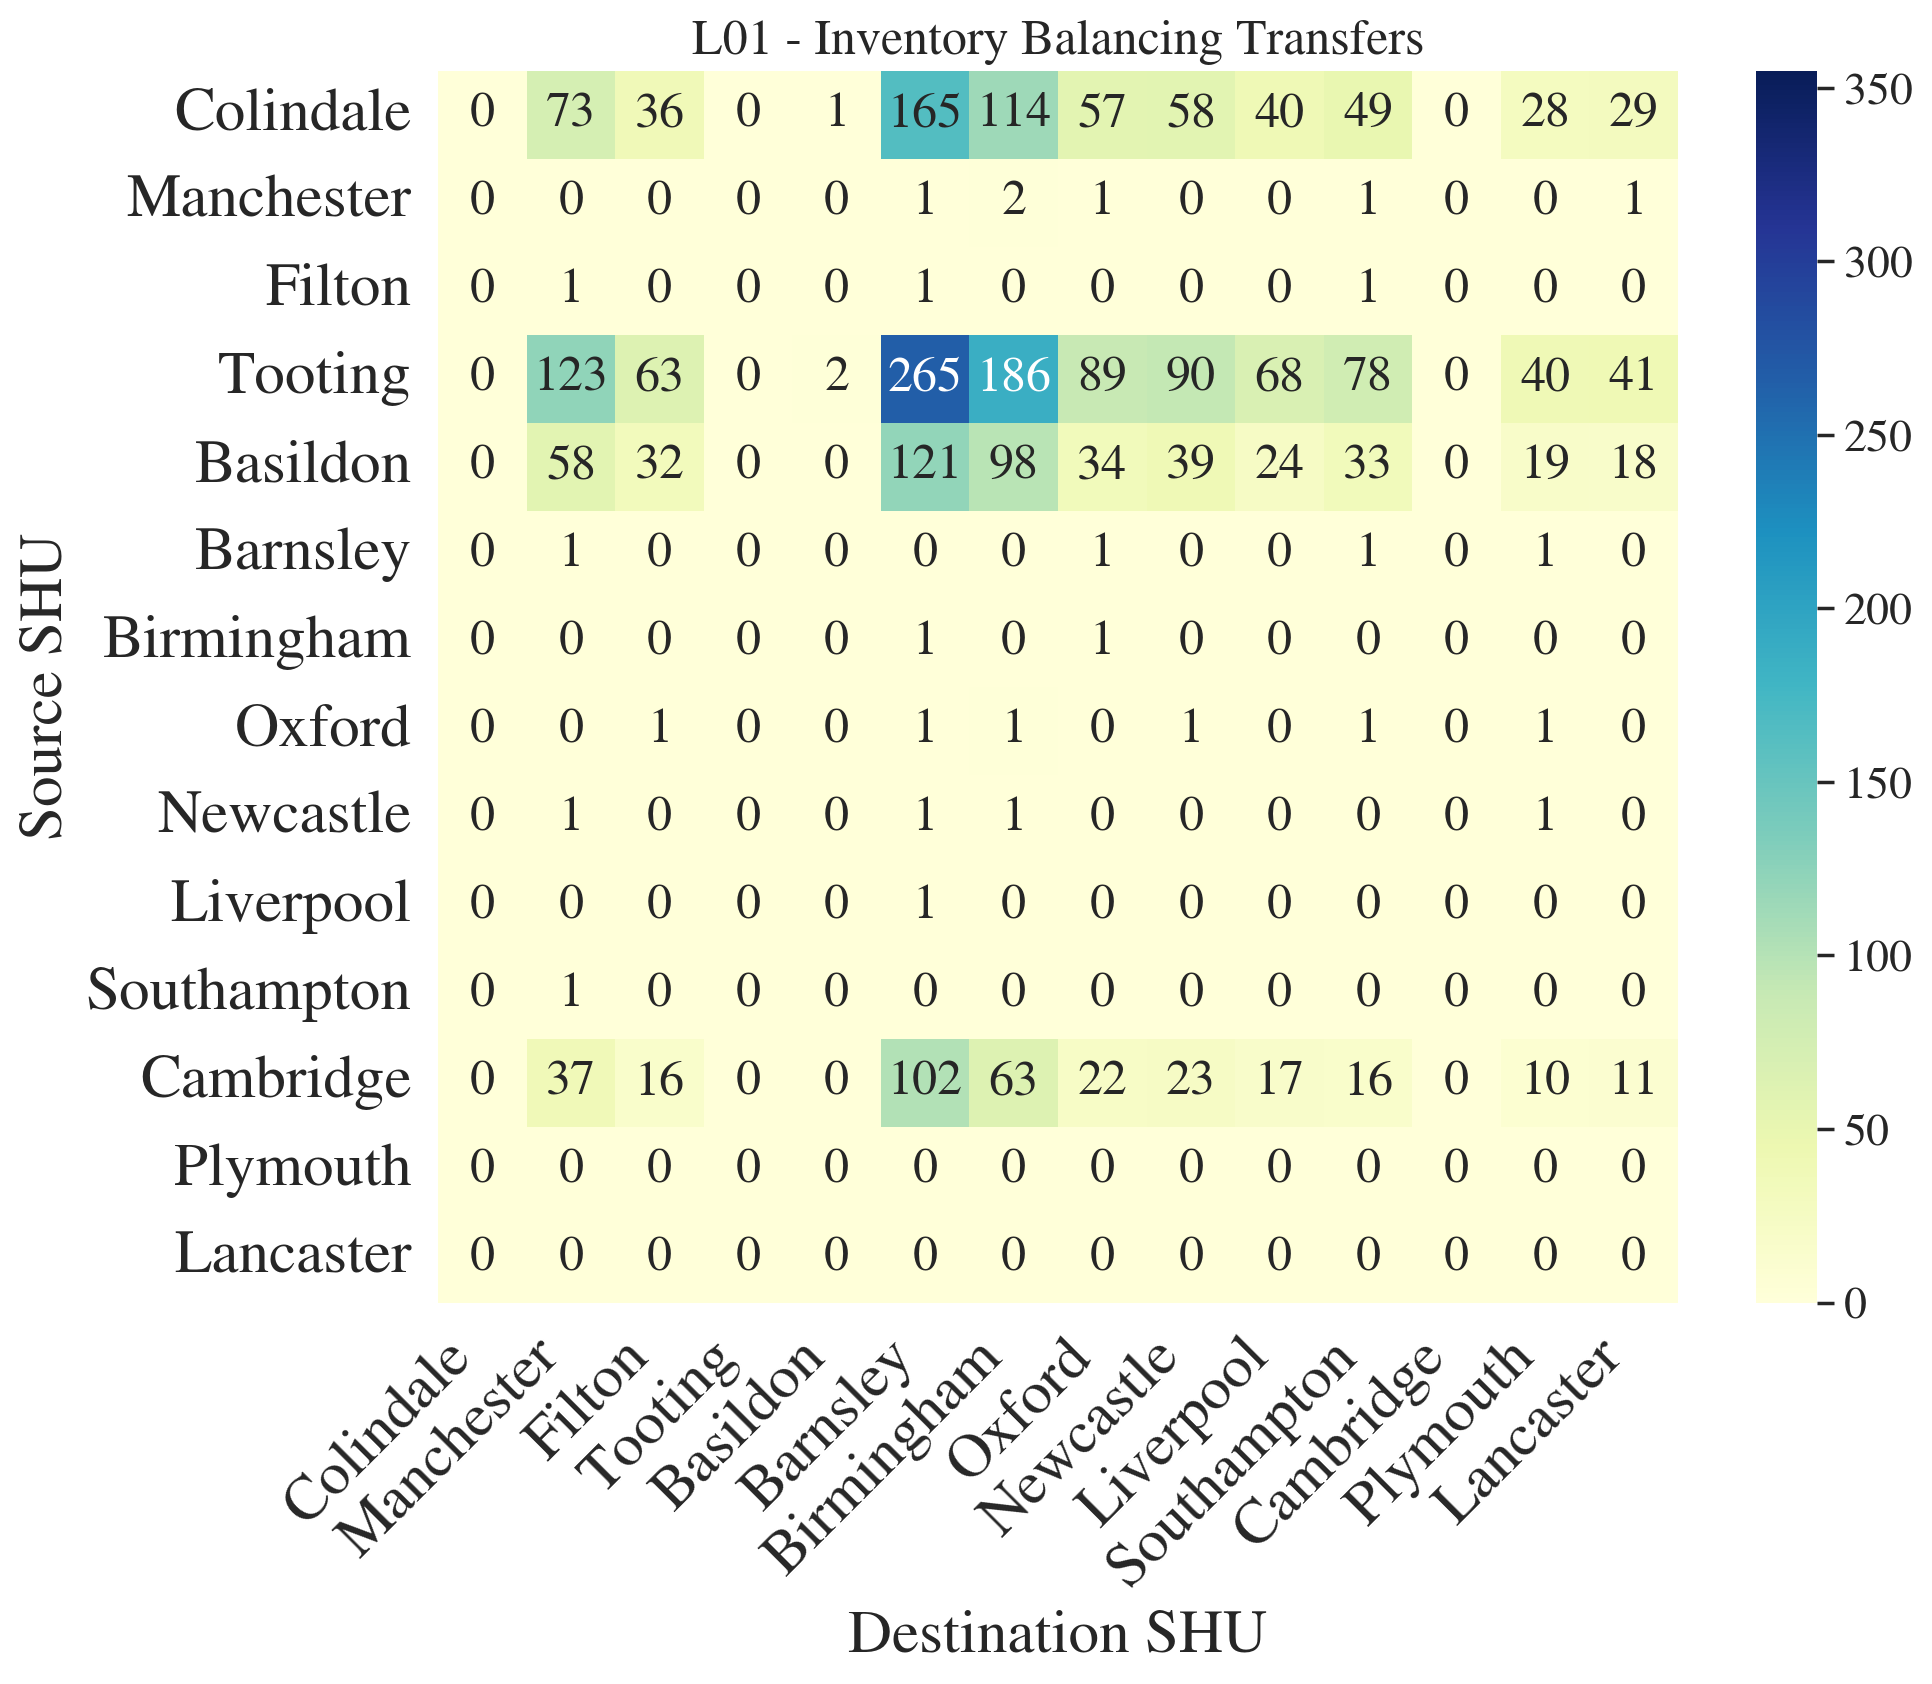

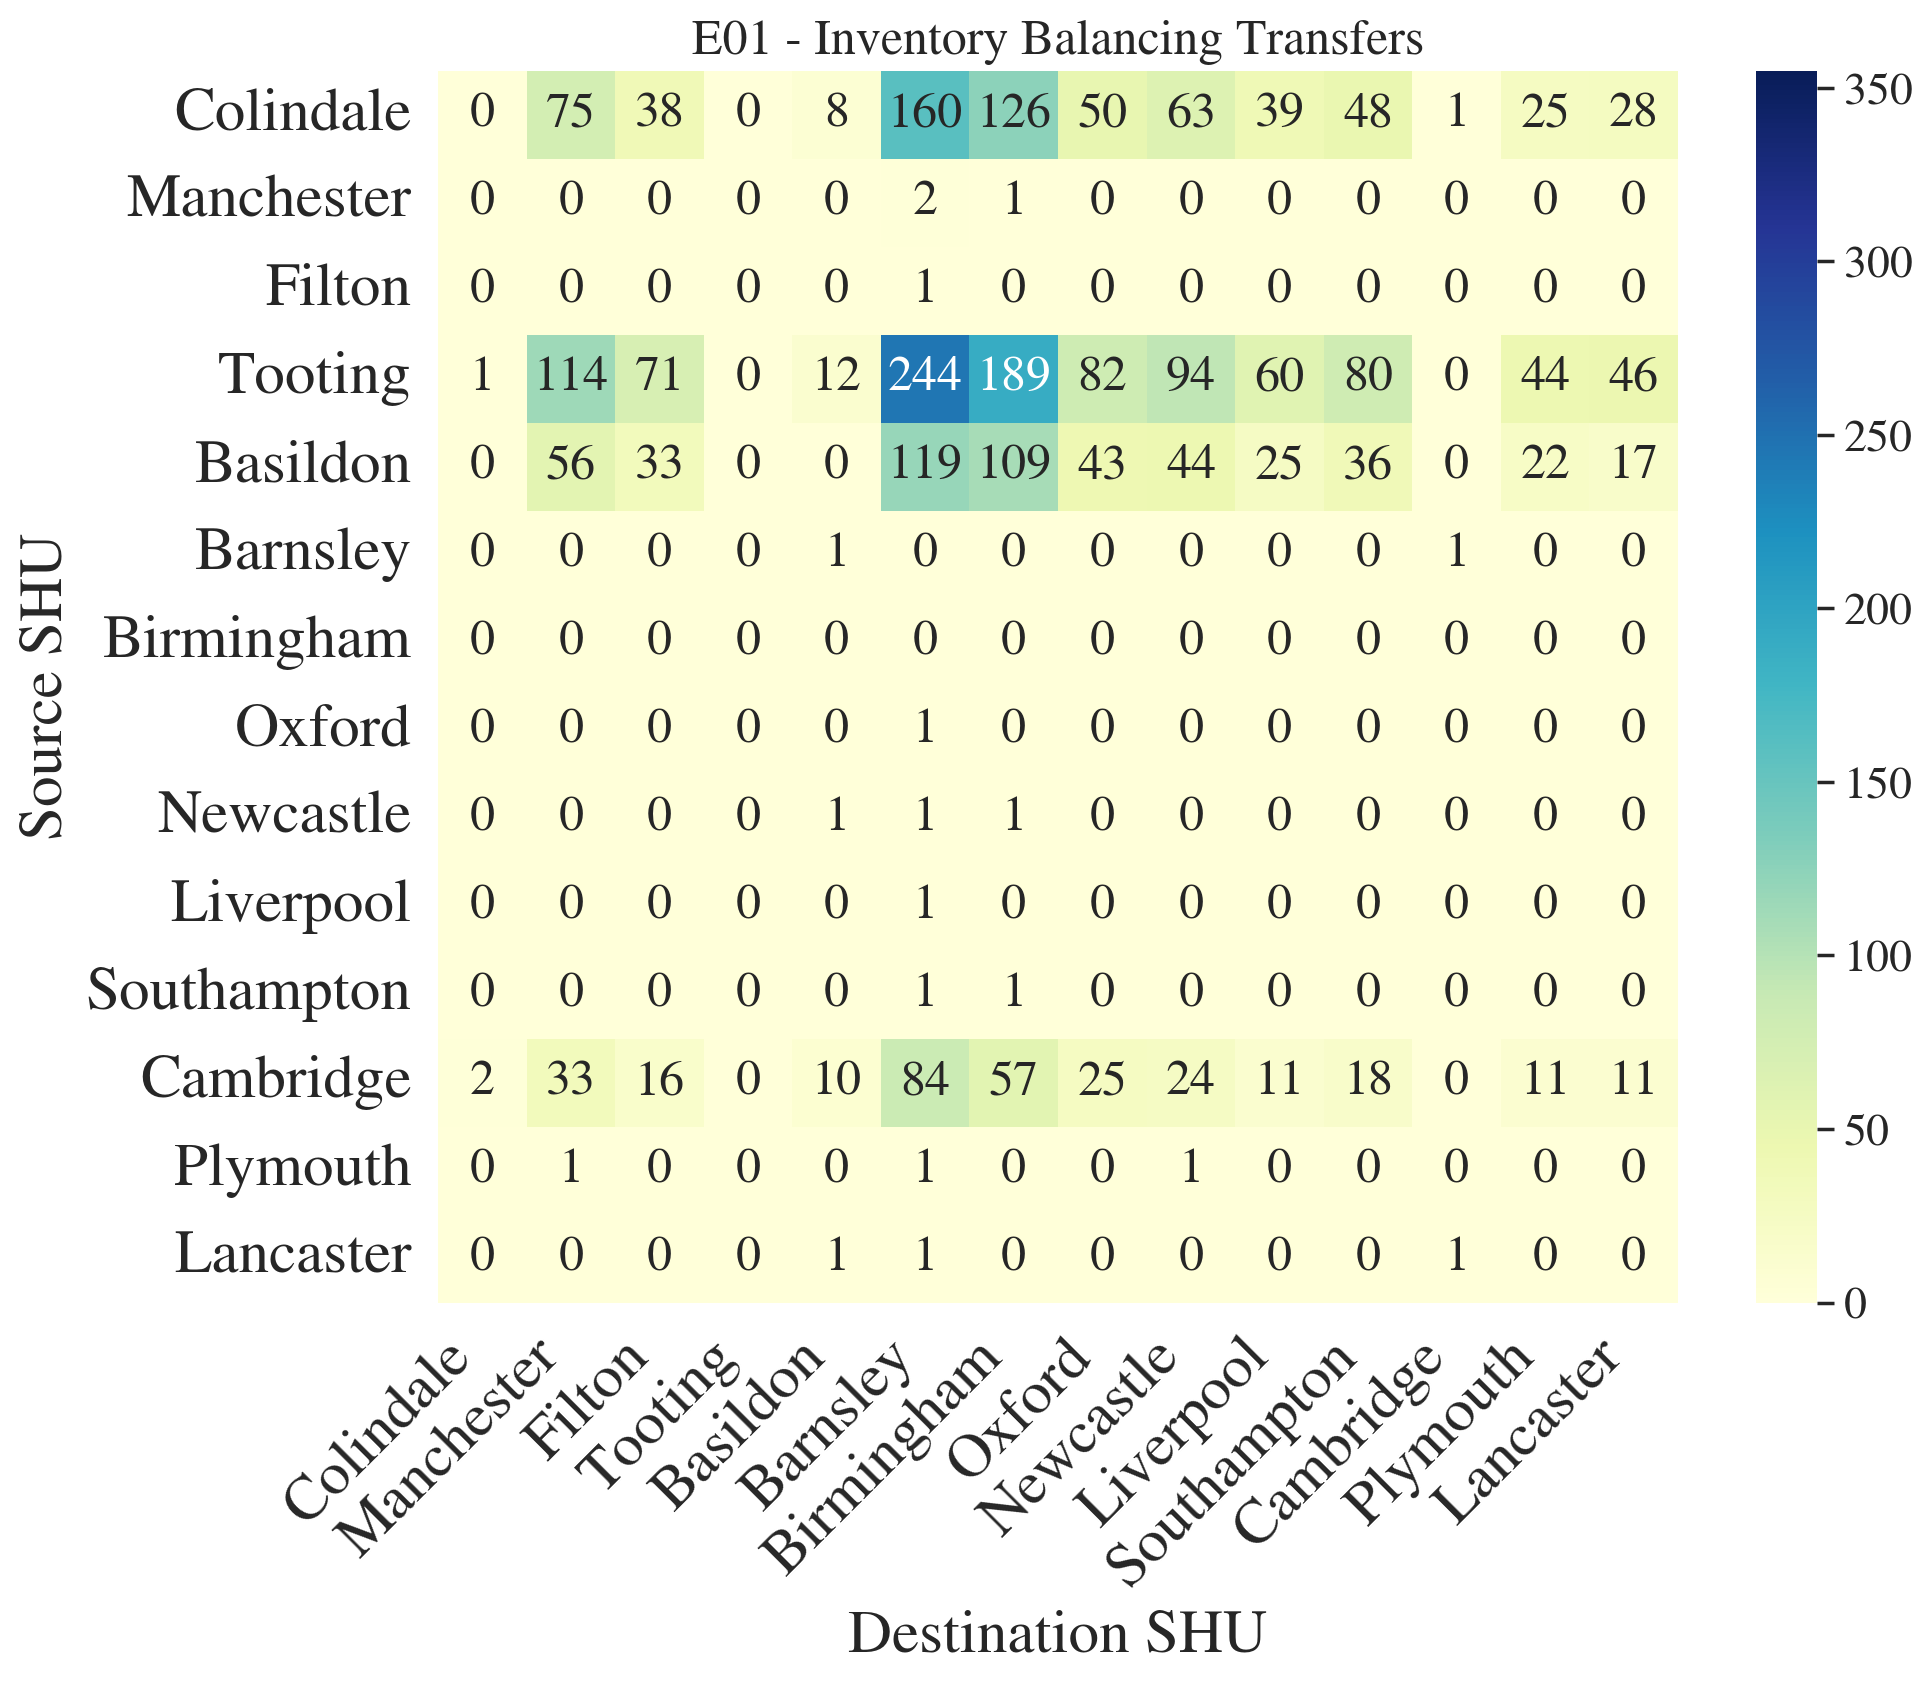

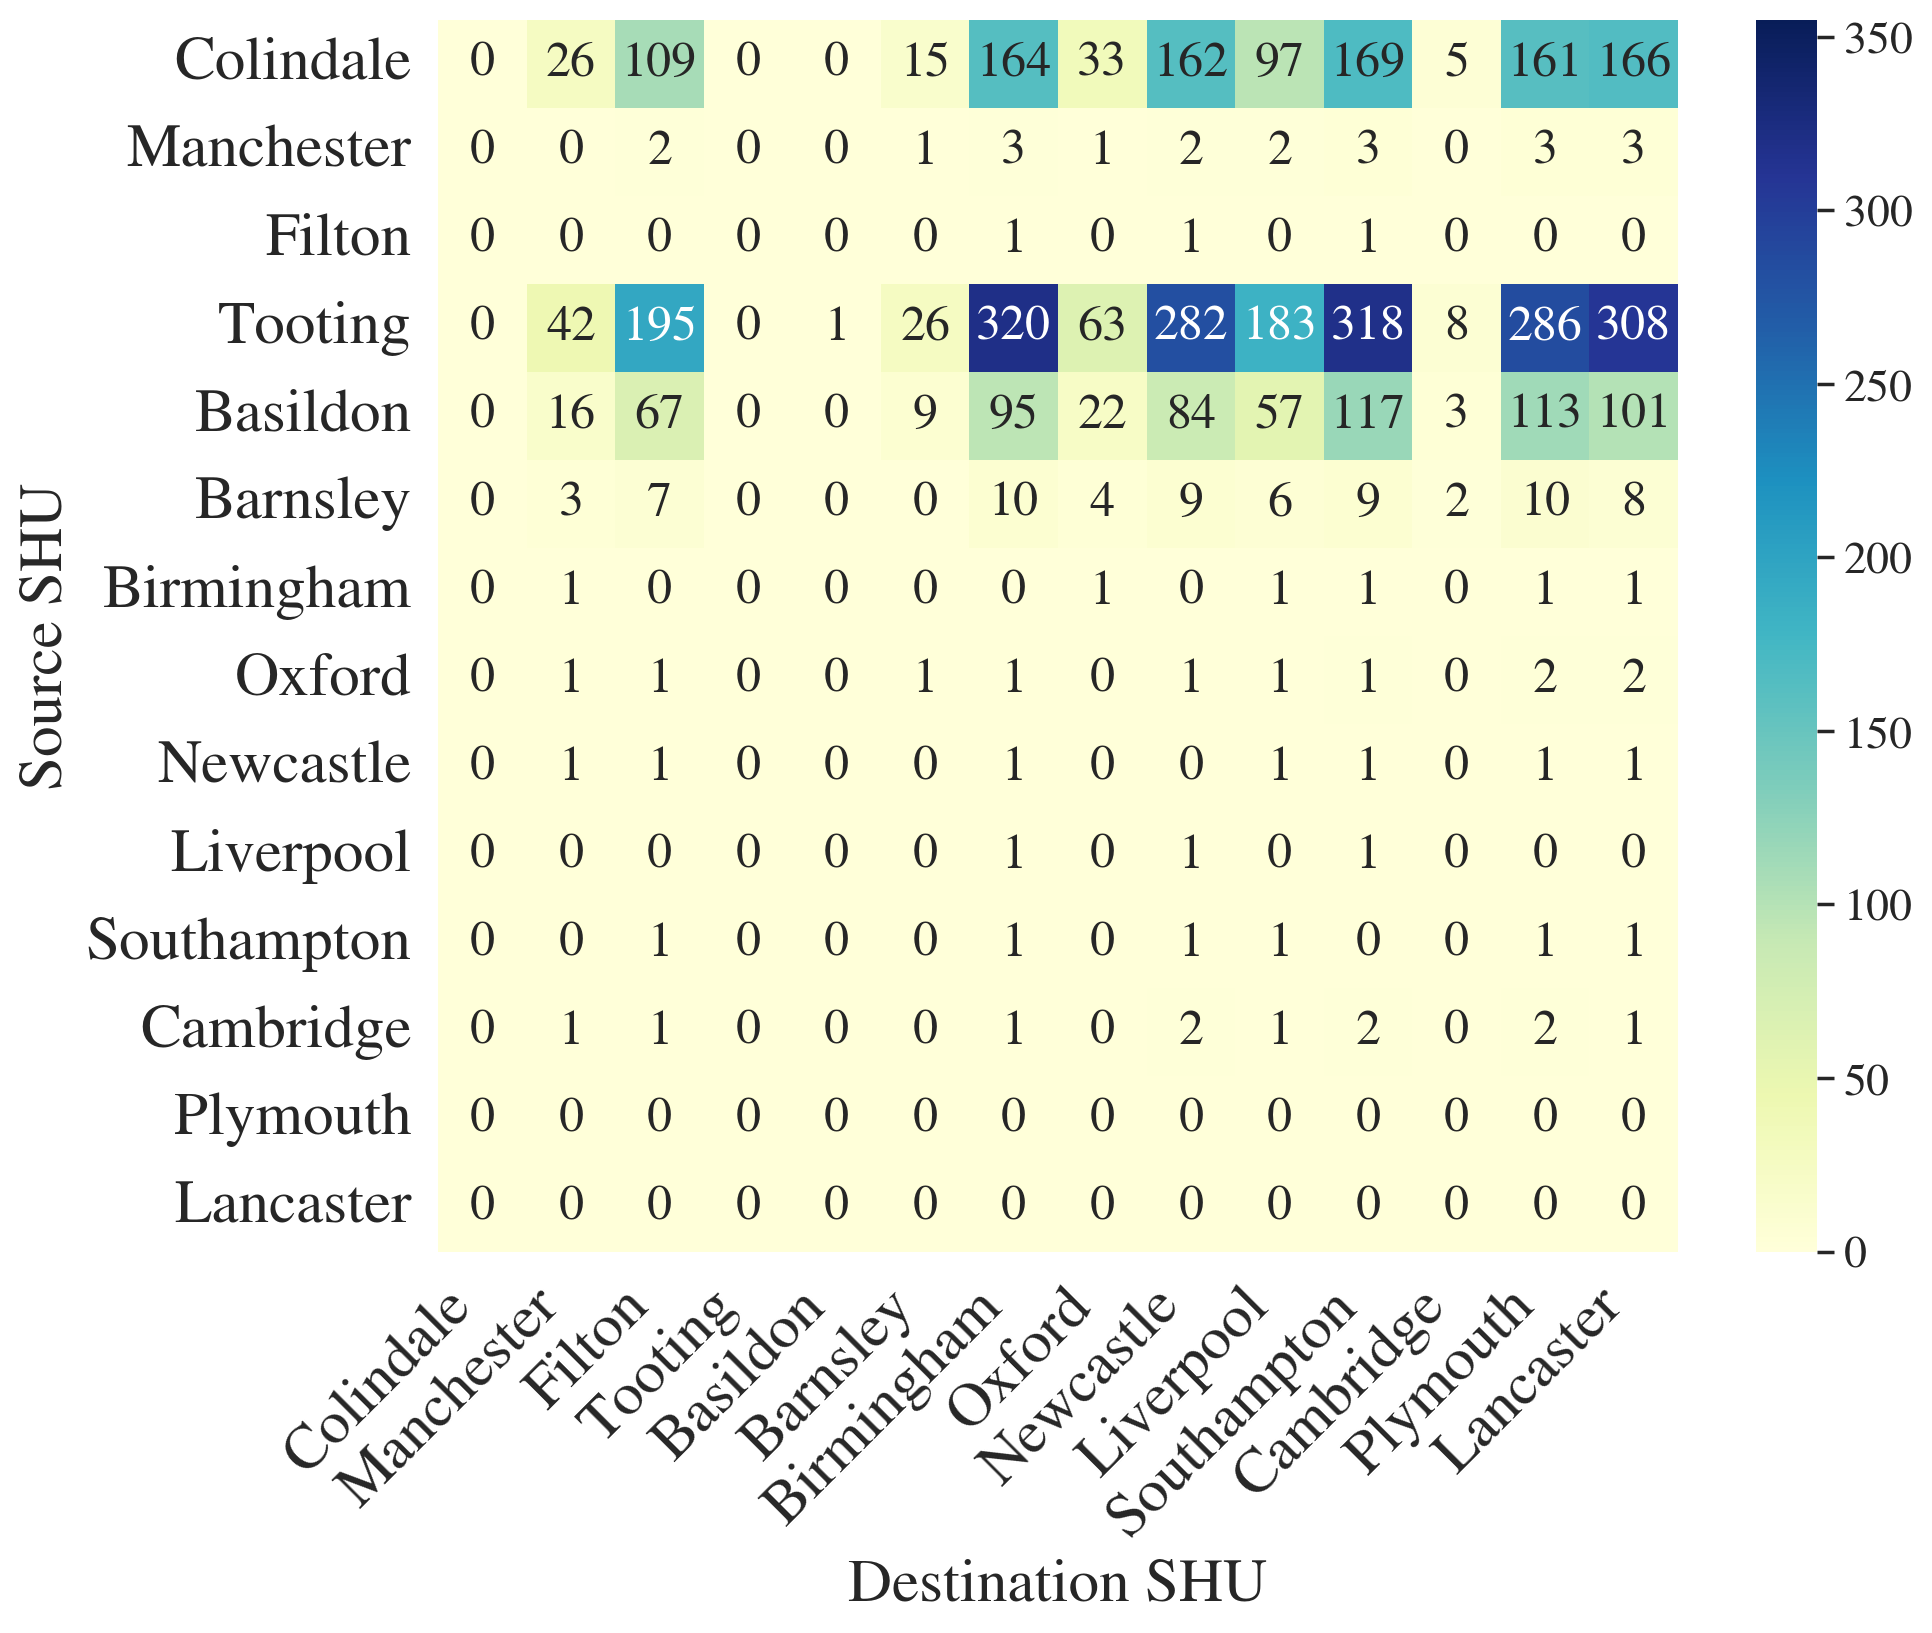

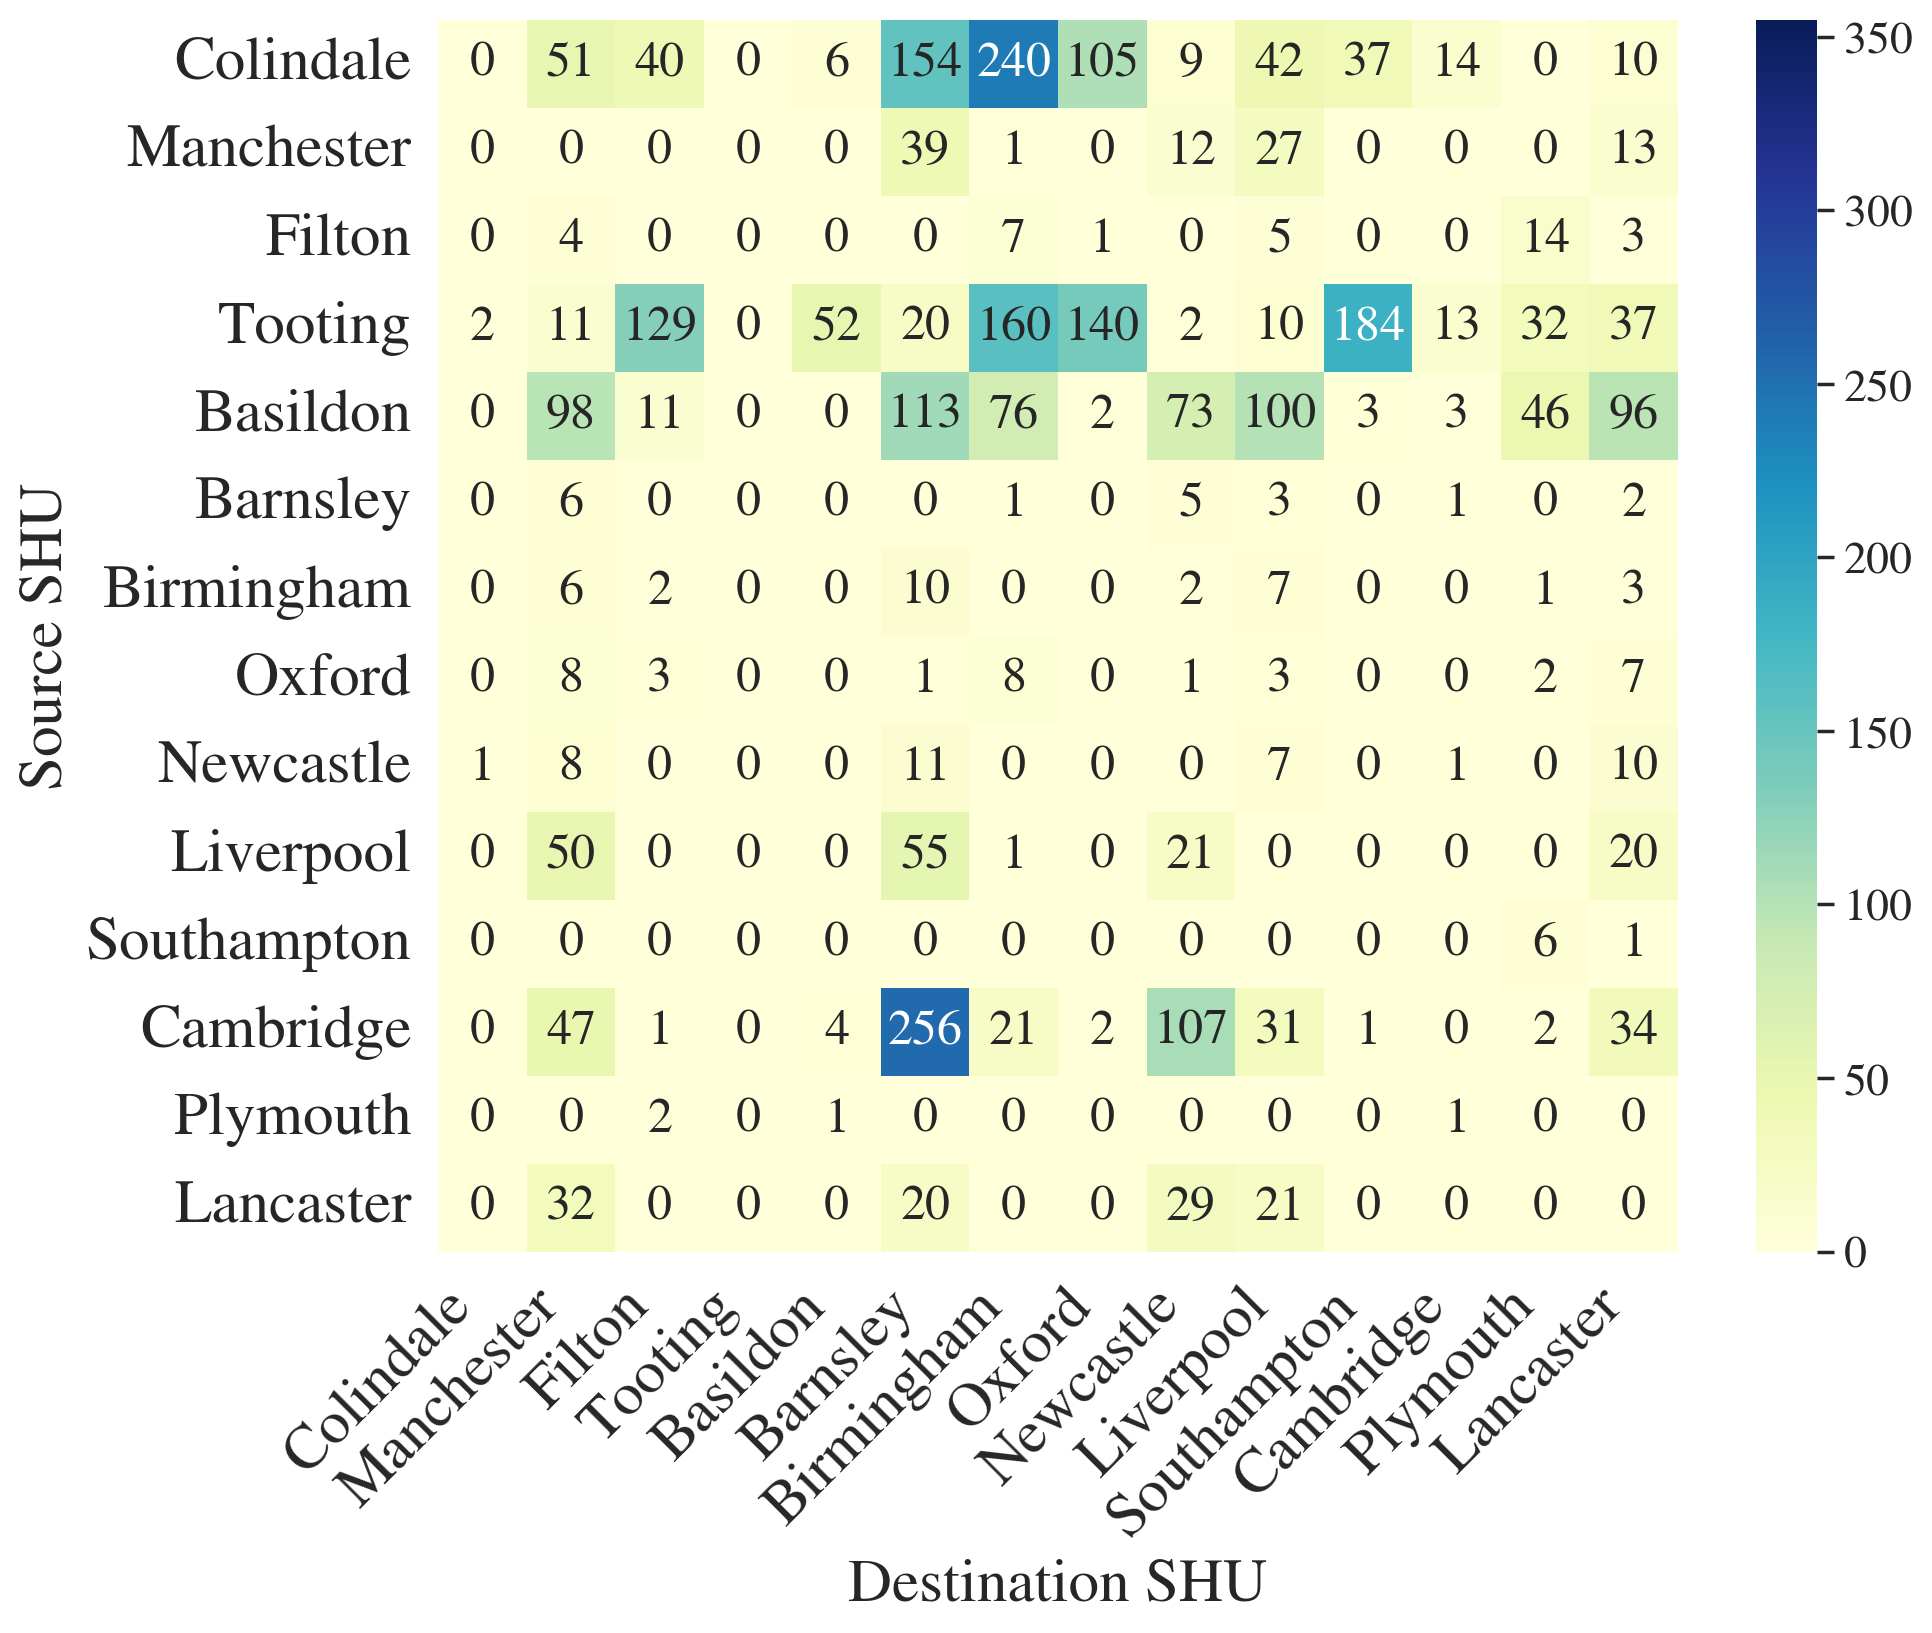

In [15]:
rebalance_mats = cf.plot_moves_matrix(
                     [limited_siloed_shus, siloed_shus,
                      shus_zero_transportation, shus_transportation_penalty,],
                     titles=['L01 - Inventory Balancing Transfers', 
                              'E01 - Inventory Balancing Transfers', 
                              None,
                              None,],
                     moves_reason='rebalancing',
                     vmax=355,
                     order_of_shus=order_of_locations_by_scd_demand, return_matrices=True,
                     pdfs=[None, None, 'scratch/figures/Hermes/E02-rebalance-moves.pdf',
                          'scratch/figures/Hermes/E03-rebalance-moves.pdf',],
                     fontsize=22,)

In [16]:
rebalance_dest_sums = [mat.sum(axis=0) for mat in rebalance_mats]
rebalance_dest_sums_df = pd.DataFrame(rebalance_dest_sums,
                                        # index=['L01', 'E01', 'E02', 'E03',],
                                        # columns=list_of_locations[order_of_locations],
                                        )
rebalance_dest_sums_df.T.rename(columns={0: 'L01', 1: 'E01', 2: 'E02', 3: 'E03',}).round(2)

,L01,E01,E02,E03
Colindale,0.83,3.26,0.22,3.02
Manchester,294.04,280.45,90.79,324.02
Filton,149.58,158.42,384.92,189.92
Tooting,0.07,0.08,0.00,0.00
Basildon,3.95,33.82,1.24,62.82
Barnsley,659.52,615.36,53.84,678.74
Birmingham,466.92,484.09,596.70,516.33
Oxford,204.53,201.58,125.22,249.48
Newcastle,213.47,226.27,544.85,262.35
Liverpool,150.56,136.18,349.23,255.63


~~With **E03**, the variance in the proportion of the total number of moves for inventory balances received at each SHU is the lowest of all four scenarios.
This is actually mirrored in the number of moves leaving each SHU, where the variance is also the lowest.~~

In [17]:
rebalance_source_sums = [mat.sum(axis=1) for mat in rebalance_mats]
rebalance_source_sums_df = pd.DataFrame(rebalance_source_sums,
                                        # index=['L01', 'E01', 'E02', 'E03',],
                                        # columns=list_of_locations[order_of_locations],
                                        )
rebalance_source_sums_df.T.rename(columns={0: 'L01', 1: 'E01', 2: 'E02', 3: 'E03',}).round(2)

,L01,E01,E02,E03
Colindale,649.87,661.21,1107.30,707.90
Manchester,6.69,3.69,19.17,93.49
Filton,3.77,2.61,3.91,34.71
Tooting,1044.81,1036.18,2031.92,792.15
Basildon,475.89,502.43,683.91,621.95
Barnsley,5.34,3.19,67.22,17.82
Birmingham,3.79,1.69,5.69,31.38
Oxford,7.37,2.21,10.66,33.49
Newcastle,3.76,4.22,8.10,38.04
Liverpool,3.37,2.65,3.99,146.17


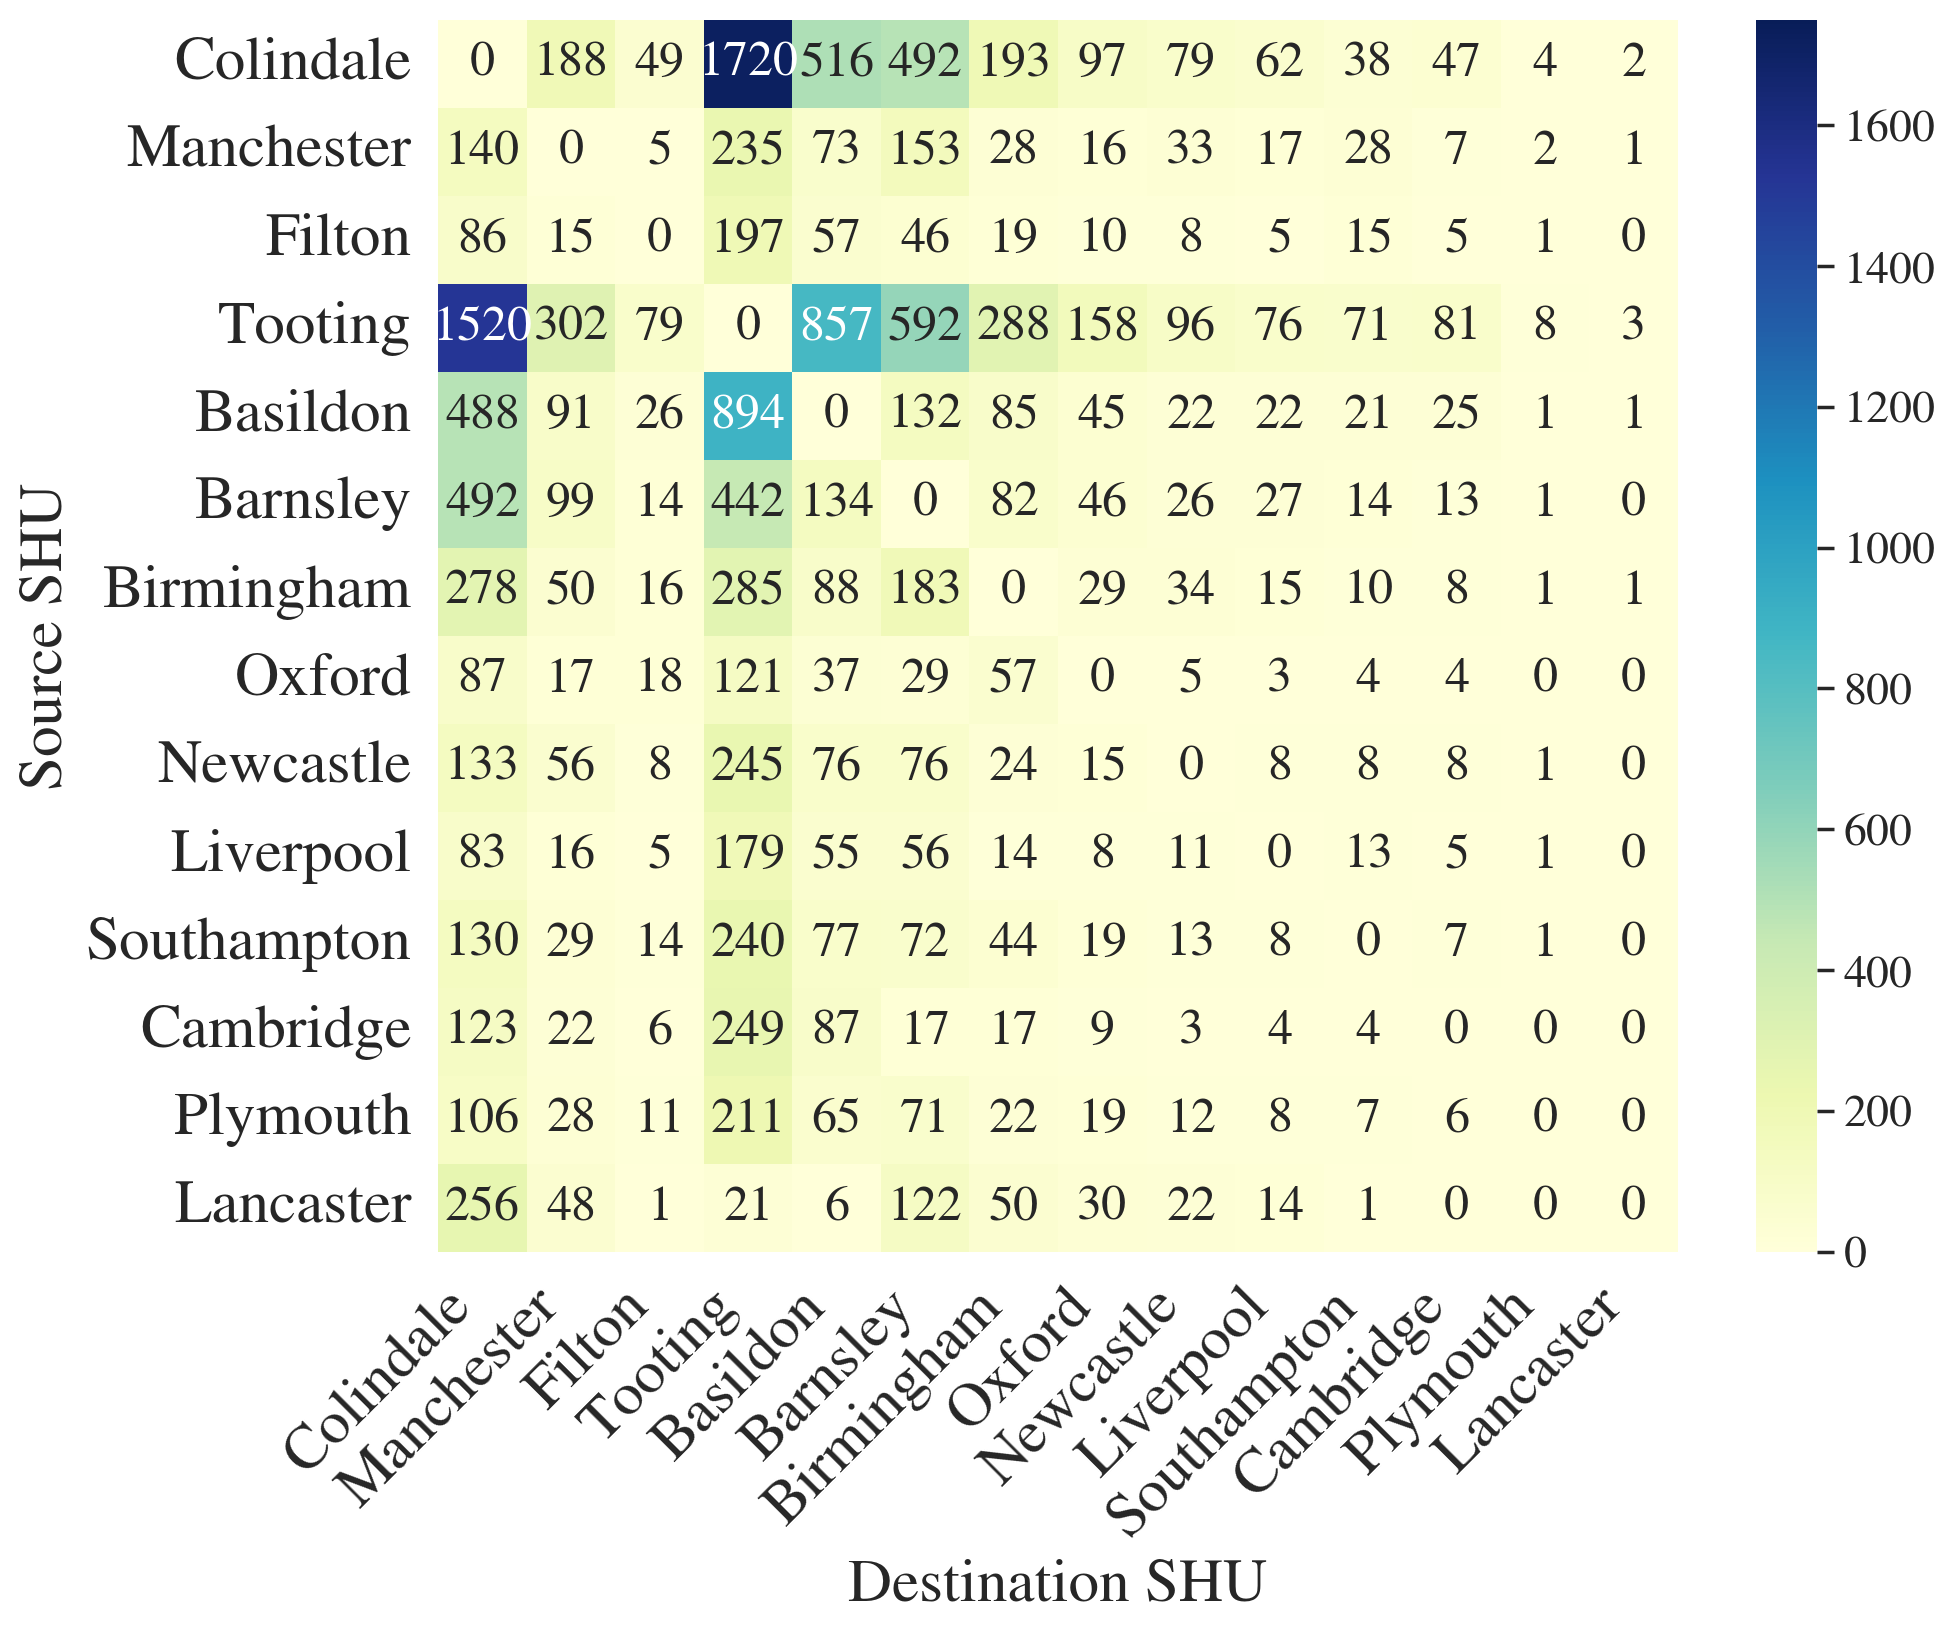

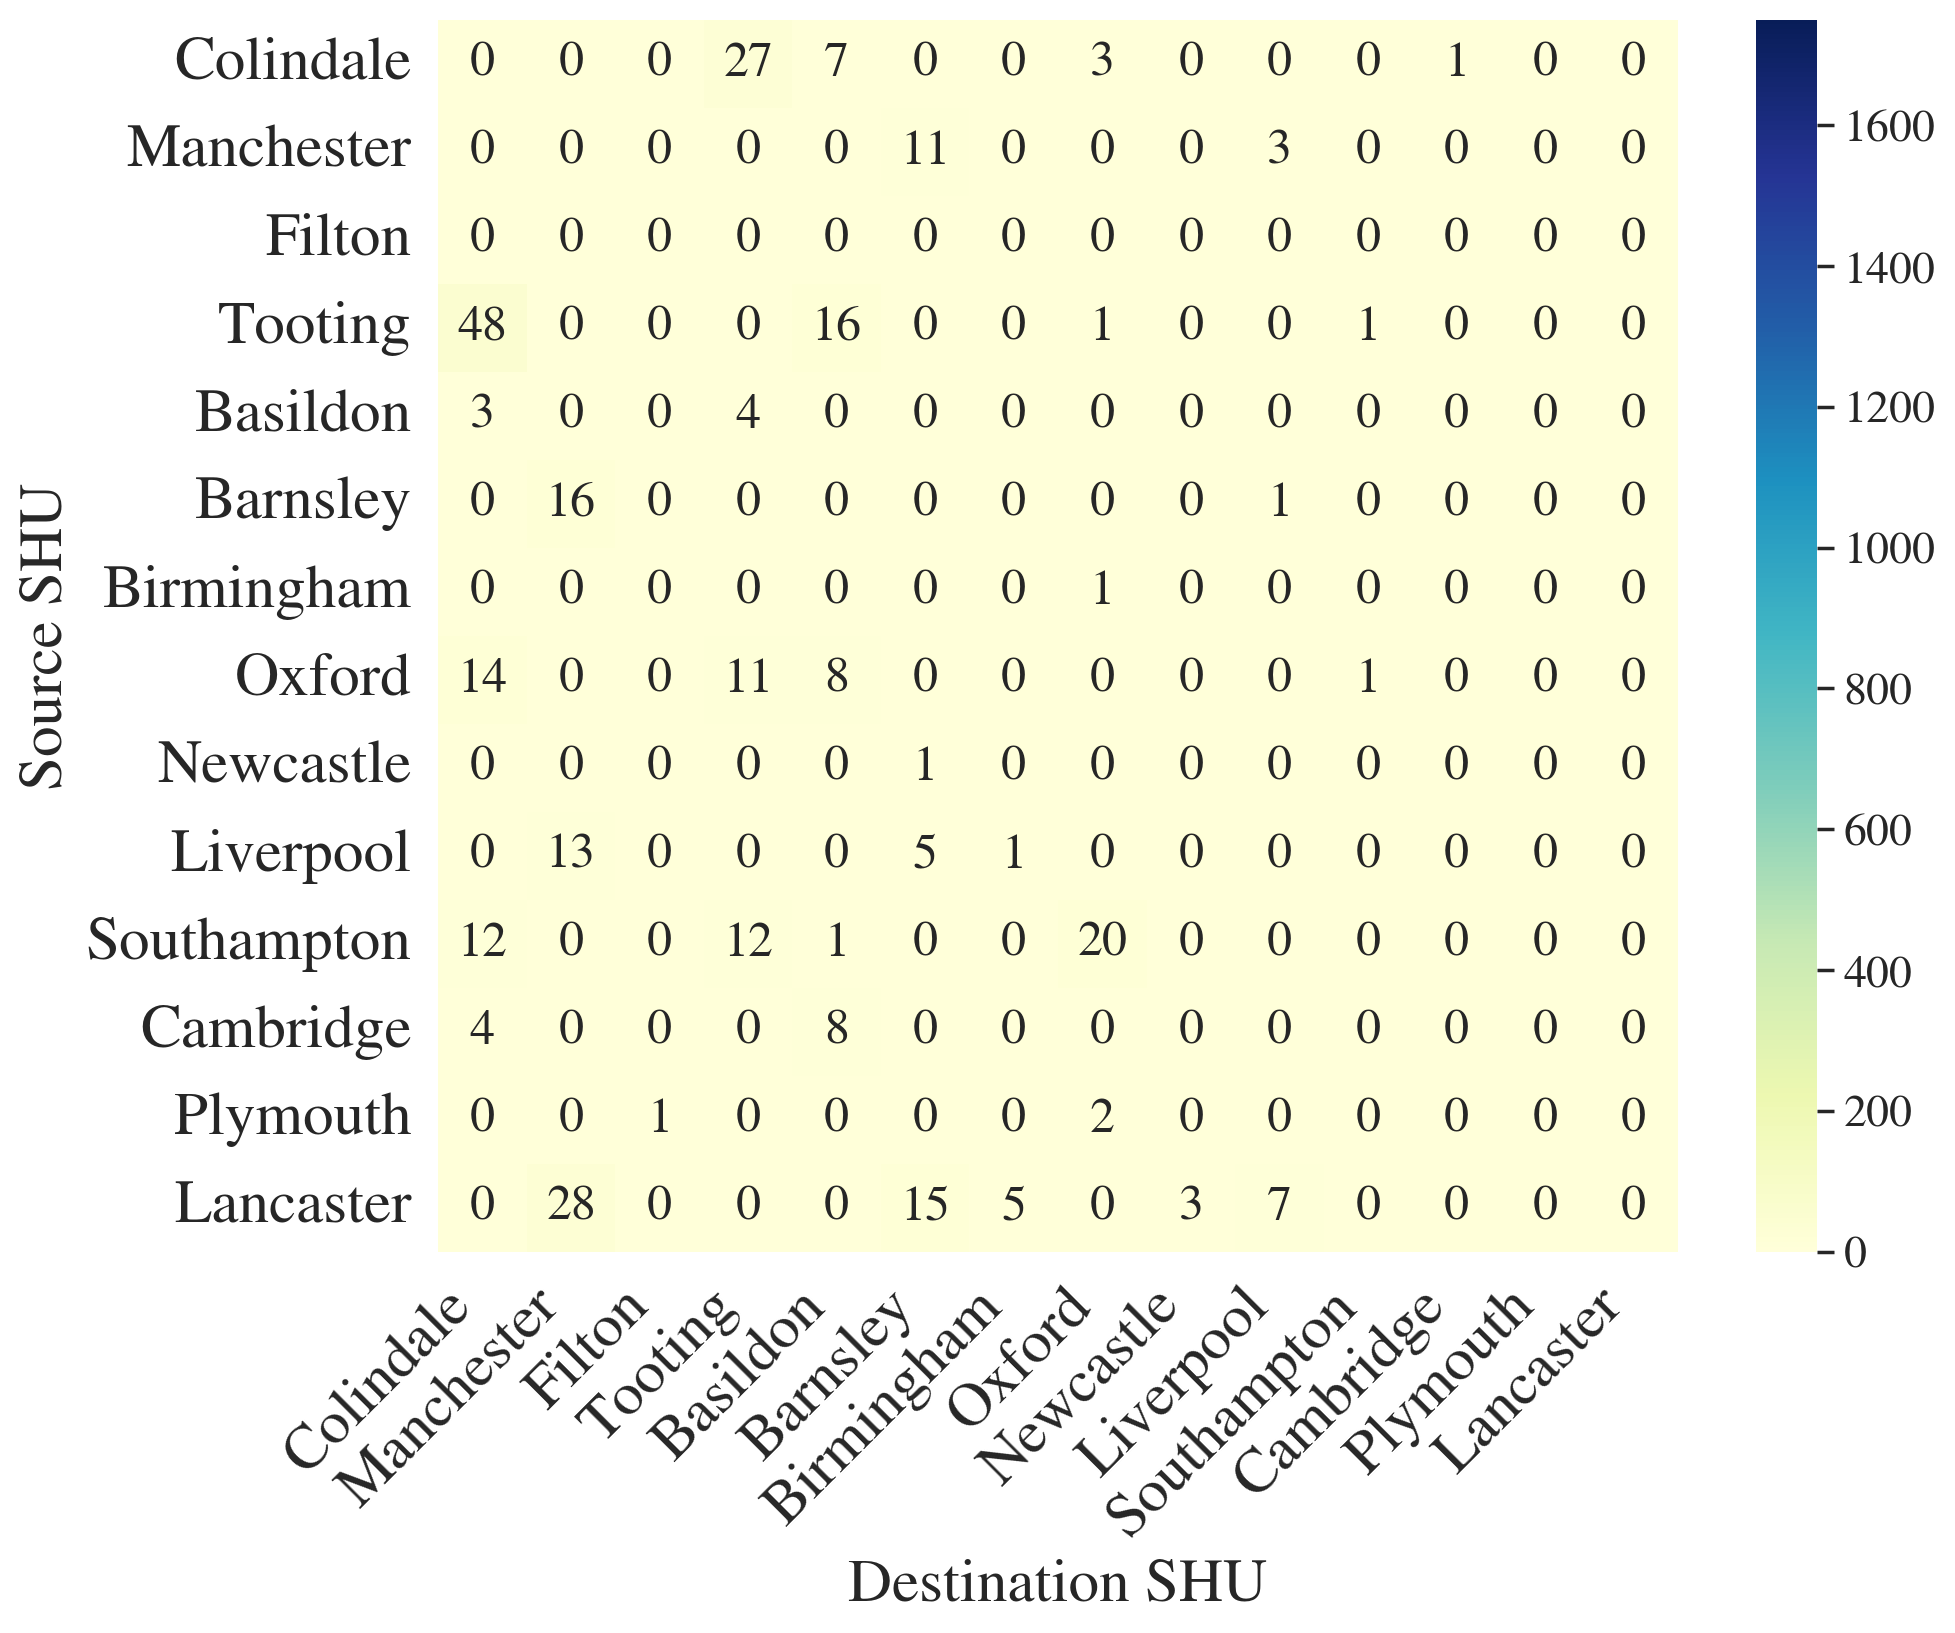

In [18]:
scd_mats = cf.plot_moves_matrix([ shus_zero_transportation, shus_transportation_penalty,],
                     titles=[None, None,],
                     moves_reason='SCD',
                     vmax=1750,
                     pdfs=['scratch/figures/Hermes/E02-scd-moves-matrix.pdf',
                          'scratch/figures/Hermes/E03-scd-moves-matrix.pdf',],
                     order_of_shus=order_of_locations_by_scd_demand, return_matrices=True,
                     fontsize=22,)

In [19]:
scd_dest_sums = [mat.sum(axis=0) for mat in scd_mats]
scd_dest_sums_df = pd.DataFrame(scd_dest_sums,
                                        # index=['E02', 'E03',],
                                        # columns=list_of_locations[order_of_locations],
                                        )
scd_dest_sums_df.T.rename(columns={0: 'E02', 1: 'E03',}).round(2)

,E02,E03
Colindale,3920.47,81.99
Manchester,961.12,57.37
Filton,250.60,0.96
Tooting,5038.10,53.36
Basildon,2127.87,39.79
Barnsley,2040.17,32.70
Birmingham,922.78,6.88
Oxford,500.59,27.29
Newcastle,363.19,2.88
Liverpool,268.21,11.52


Top five destinations were (in descending order): Tooting, Colindale, Basildon, Barnsley, and Manchester for E02 in SCD moves. These receive about $83\%$ of all SCD moves. For E03, the top five destinations are Colindale, Manchester, Tooting, Basildon, and Barnsley. They receive $83\%$ of all SCD moves.

Noteworthy that Birmingham is not in the former list despite being one of the five SHUs that is regularly stocked with R<sub>0</sub> units.
It must be said that although Birmingham does have over 1.5 times the overall demand as Manchester, it only has ~$87\%$ of Manchester's R0 demand and almost identical SCD demand. It's not clear then, why Birmingham is one of the SHUs that regularly stocks R0 units.

According to Kirk, R0 demand at Manchester is met adhoc by taking what is available at Manchester before it gets sent to Tooting/Birmingham. Only demand on the day is taken ad-hoc like this. This is a manual process and not something that is currently automated. It is also not something that is currently captured in the model.

In [20]:
scd_source_sums = [mat.sum(axis=1) for mat in scd_mats]
scd_source_sums_df = pd.DataFrame(scd_source_sums,
                                        # index=['E02', 'E03',],
                                        # columns=list_of_locations[order_of_locations],
                                        )
scd_source_sums_df.T.rename(columns={0: 'E02', 1: 'E03',}).round(2)

,E02,E03
Colindale,3487.16,37.15
Manchester,737.59,14.49
Filton,465.34,0.51
Tooting,4130.51,66.93
Basildon,1852.77,7.44
Barnsley,1389.69,18.15
Birmingham,997.42,1.77
Oxford,380.89,35.03
Newcastle,658.54,1.13
Liverpool,445.67,19.52


The top five origins were (in descending order): Tooting, Colindale, Basildon, Barnsley, and Birmingham for E02 in SCD moves. These account for about $70\%$ of all SCD moves.
For E03, the top five origins are Tooting, Lancaster, Southampton, Colindale, and Oxford. They account for about $76\%$ of all SCD moves.

~~Not completely unsurprising that Filton and Manchester are the only SHUs that have an increase in the number of outgoing moves when the the transportation penalty is introduced.~~
~~We think this is because they are hub SHUs so are by definition, 'closer' or 'central' to the other SHUs in their region(s) and transportation/courier costs would be lower.~~

### Top/Bottom Shipping Pairs

In [21]:
mats_labels = ['SHUs Zero Transportation', 'SHUs Transportation Penalty',]
cf.print_top_bottom_pairs_unidirectional(scd_mats, n=10, labels=mats_labels,)

Top/Bottom 10 unidirectional shipping pairs for SHUs Zero Transportation:
Top 10 shipping pairs (source, dest, units moved):
   Source SHU Destination SHU  Units Moved
1   Colindale         Tooting      1719.77
2     Tooting       Colindale      1519.53
3    Basildon         Tooting       894.16
4     Tooting        Basildon       857.07
5     Tooting        Barnsley       591.60
6   Colindale        Basildon       515.76
7   Colindale        Barnsley       492.10
8    Barnsley       Colindale       491.75
9    Basildon       Colindale       487.67
10   Barnsley         Tooting       441.75
Bottom 10 shipping pairs (source, dest, units moved):
      Source SHU Destination SHU  Units Moved
159    Lancaster       Cambridge         0.43
160    Liverpool       Lancaster         0.43
161     Barnsley       Lancaster         0.33
162  Southampton       Lancaster         0.32
163    Newcastle       Lancaster         0.28
164     Plymouth       Lancaster         0.23
165    Cambridge        Pl

In [22]:
print('Top/Bottom Bilateral Shipping Pairs for SHUs Zero Transportation:\n')
ranked_pairs = cf.top_bottom_pairs_bidirectional(scd_mats[0], n=10, both=True,)
print('Top 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):')
print(ranked_pairs[0])
print('Bottom 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):')
print(ranked_pairs[1])

Top/Bottom Bilateral Shipping Pairs for SHUs Zero Transportation:

Top 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):
            i           j    score
0   Colindale     Tooting  3239.30
1     Tooting    Basildon  1751.23
2     Tooting    Barnsley  1033.35
3   Colindale    Basildon  1003.43
4   Colindale    Barnsley   983.85
5     Tooting  Birmingham   572.56
6  Manchester     Tooting   537.32
7   Colindale  Birmingham   471.03
8     Tooting   Newcastle   341.60
9     Tooting   Cambridge   329.36
Bottom 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):
             i          j  score
0       Filton  Liverpool   9.80
1    Liverpool  Cambridge   9.22
2    Liverpool   Plymouth   8.95
3  Southampton   Plymouth   7.96
4     Basildon  Lancaster   6.67
5    Cambridge   Plymouth   6.25
6       Filton  Lancaster   1.38
7  Southampton  Lancaster   1.13
8    Cambridge  Lancaster   0.45
9     Plymouth  Lancaster   0.29


In [23]:
print('Top/Bottom Bilateral Shipping Pairs for SHUs Transportation Penalty:\n')
ranked_pairs: pd.DataFrame = cf.top_bottom_pairs_bidirectional(scd_mats[1], n=10, both=True,)
print('Top 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):')
print(ranked_pairs[0])
print('Bottom 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved (score)):')
print(ranked_pairs[1])

Top/Bottom Bilateral Shipping Pairs for SHUs Transportation Penalty:

Top 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved):
            i            j  score
0   Colindale      Tooting  75.35
1  Manchester    Lancaster  28.28
2  Manchester     Barnsley  27.37
3      Oxford  Southampton  20.99
4     Tooting     Basildon  19.94
5   Colindale       Oxford  17.00
6  Manchester    Liverpool  15.94
7    Barnsley    Lancaster  14.58
8     Tooting  Southampton  12.45
9     Tooting       Oxford  11.98
Bottom 5 bilateral shipping pairs (loc1 (i), loc2 (j), total units moved (score)):
            i            j  score
0  Manchester  Southampton    0.0
1  Manchester    Cambridge    0.0
2   Colindale    Liverpool    0.0
3      Oxford    Newcastle    0.0
4   Newcastle    Cambridge    0.0
5   Newcastle     Plymouth    0.0
6   Newcastle  Southampton    0.0
7   Colindale    Newcastle    0.0
8   Colindale     Barnsley    0.0
9   Colindale   Manchester    0.0


### Maximum number of moves in a day

In [24]:
max_num_moves_dict = cf.max_number_of_moves_in_a_day([ shus_zero_transportation, shus_transportation_penalty,],
                                                     id_shu_dict,
                                                     warm_up=warmup_period, move_reason=move_reasons['SCD'],
                                                     )
max_moves_dict= {}
for k, v in all_results.items():
    if v not in max_num_moves_dict.keys():
        continue
    print(f"Max number of moves in a day for {scenario_labels[k]}: {max_num_moves_dict[v]['mean_max_overall']:.1f} ± {max_num_moves_dict[v]['std_err_max_overall']:.2f}.")
    # print('By SHU:')
    shu_moves_list = [f"{max_num_moves_dict[v]['mean_max_each_shu'][loc]:.1f} ± {max_num_moves_dict[v]['std_err_max_each_shu'][loc]:.2f}" for loc in range(len(list_of_location_ids))]    
    # shu_moves_list = [f"{max_num_moves_dict[v]['shu_names'][loc]}: {max_num_moves_dict[v]['mean_max_each_shu'][loc]} ± {max_num_moves_dict[v]['std_err_max_each_shu'][loc]}" for loc in range(len(list_of_location_ids))]
    # print(' '.join(shu_moves_list))
    print()
    max_moves_dict.update({scenario_labels_compact[k]: shu_moves_list})

pd.DataFrame(max_moves_dict, index=list_of_locations,)

Max number of moves in a day for E02: SHUs with Zero Transportation: 199.7 ± 1.99.

Max number of moves in a day for E03: SHUs with Transportation Penalty: 42.1 ± 1.80.



,E02,E03
SHU_Colindale,154.0 ± 1.09,7.9 ± 0.44
SHU_Filton,44.8 ± 1.42,0.4 ± 0.10
SHU_Manchester,47.2 ± 0.83,5.4 ± 0.32
SHU_Tooting,199.5 ± 1.98,16.1 ± 1.01
SHU_Basildon,87.0 ± 0.91,2.6 ± 0.19
SHU_Cambridge,33.6 ± 0.48,4.0 ± 0.22
SHU_Plymouth,64.8 ± 1.38,2.6 ± 0.47
SHU_Southampton,77.6 ± 2.25,16.8 ± 1.12
SHU_Birmingham,64.3 ± 1.73,1.4 ± 0.22
SHU_Oxford,36.6 ± 1.30,14.2 ± 1.16


### Distribution of the number of multiple moves

In [25]:
# cf.distribution_multiple_moves(siloed_shus, figsize=(7, 5), title=f'{scenario_labels_compact["siloed_shus"]} - Distribution of Transfers per Unit',
#                                warmup=warmup_period,
#                                xlim=(0.5, 10),)

In [26]:
# cf.distribution_multiple_moves(shus_zero_transportation, figsize=(7, 5), title=f'{scenario_labels_compact["shus_zero_transportation"]} - Distribution of Transfers per Unit',
#                                warmup=warmup_period, xlim=(0.5, 10),)
# cf.distribution_multiple_moves(shus_transportation_penalty, figsize=(7, 5), title=f'{scenario_labels_compact["shus_transportation_penalty"]} - Distribution of Transfers per Unit',
#                                warmup=warmup_period, xlim=(0.5, 10),)

In [27]:
moves_distr_mean = {}
moves_distr_stderr = {}
temp_scenarios = ['shus_zero_transportation', 'shus_transportation_penalty', ]
for scenario in temp_scenarios:
    result = cf.distribution_multiple_moves(all_results[scenario], plot_graph=False, return_hist=True,
                                                warmup=warmup_period, move_reason=move_reasons['SCD'], shelf_life=shelf_life,)
    moves_distr_mean[scenario] = result[0]
    moves_distr_stderr[scenario] = result[1]
df = pd.DataFrame(moves_distr_mean, index=np.arange(0, shelf_life),)
df.rename(columns={scenario: scenario_labels[scenario] for scenario in temp_scenarios}, inplace=True)
df_stderr = pd.DataFrame(moves_distr_stderr, index=np.arange(0, shelf_life),)
df_stderr.rename(columns={scenario: scenario_labels[scenario] for scenario in temp_scenarios}, inplace=True)


In [28]:
df

,E02: SHUs with Zero Transportation,E03: SHUs with Transportation Penalty
0,0.00,0.00
1,9158.88,308.42
2,2154.13,5.47
3,742.76,0.00
4,217.14,0.00
5,49.23,0.00
6,9.02,0.00
7,1.48,0.00
8,0.18,0.00
9,0.01,0.00


In [29]:
# cf.distribution_multiple_moves(shus_zero_transportation, figsize=(7, 4), 
#                             #    title=f'{scenario_labels_compact["shus_zero_transportation"]} - Distribution of SCD Transfers per Unit',
#                                warmup=warmup_period, xlim=(0.5, 10), move_reason=move_reasons['SCD'],
#                                pdf=f'scratch/figures/Hermes/E02-dist-multiple-moves-scd.pdf',
#                                shelf_life=shelf_life,
#                                fontsize=22,
#                                )
# cf.distribution_multiple_moves(shus_transportation_penalty, figsize=(7, 4), 
#                             #    title=f'{scenario_labels_compact["shus_transportation_penalty"]} - Distribution of SCD Transfers per Unit',
#                                warmup=warmup_period, xlim=(0.5, 10), move_reason=move_reasons['SCD'],
#                                pdf=f'scratch/figures/Hermes/E03-dist-multiple-moves-scd.pdf',
#                                shelf_life=shelf_life,
#                                fontsize=22,
#                                )

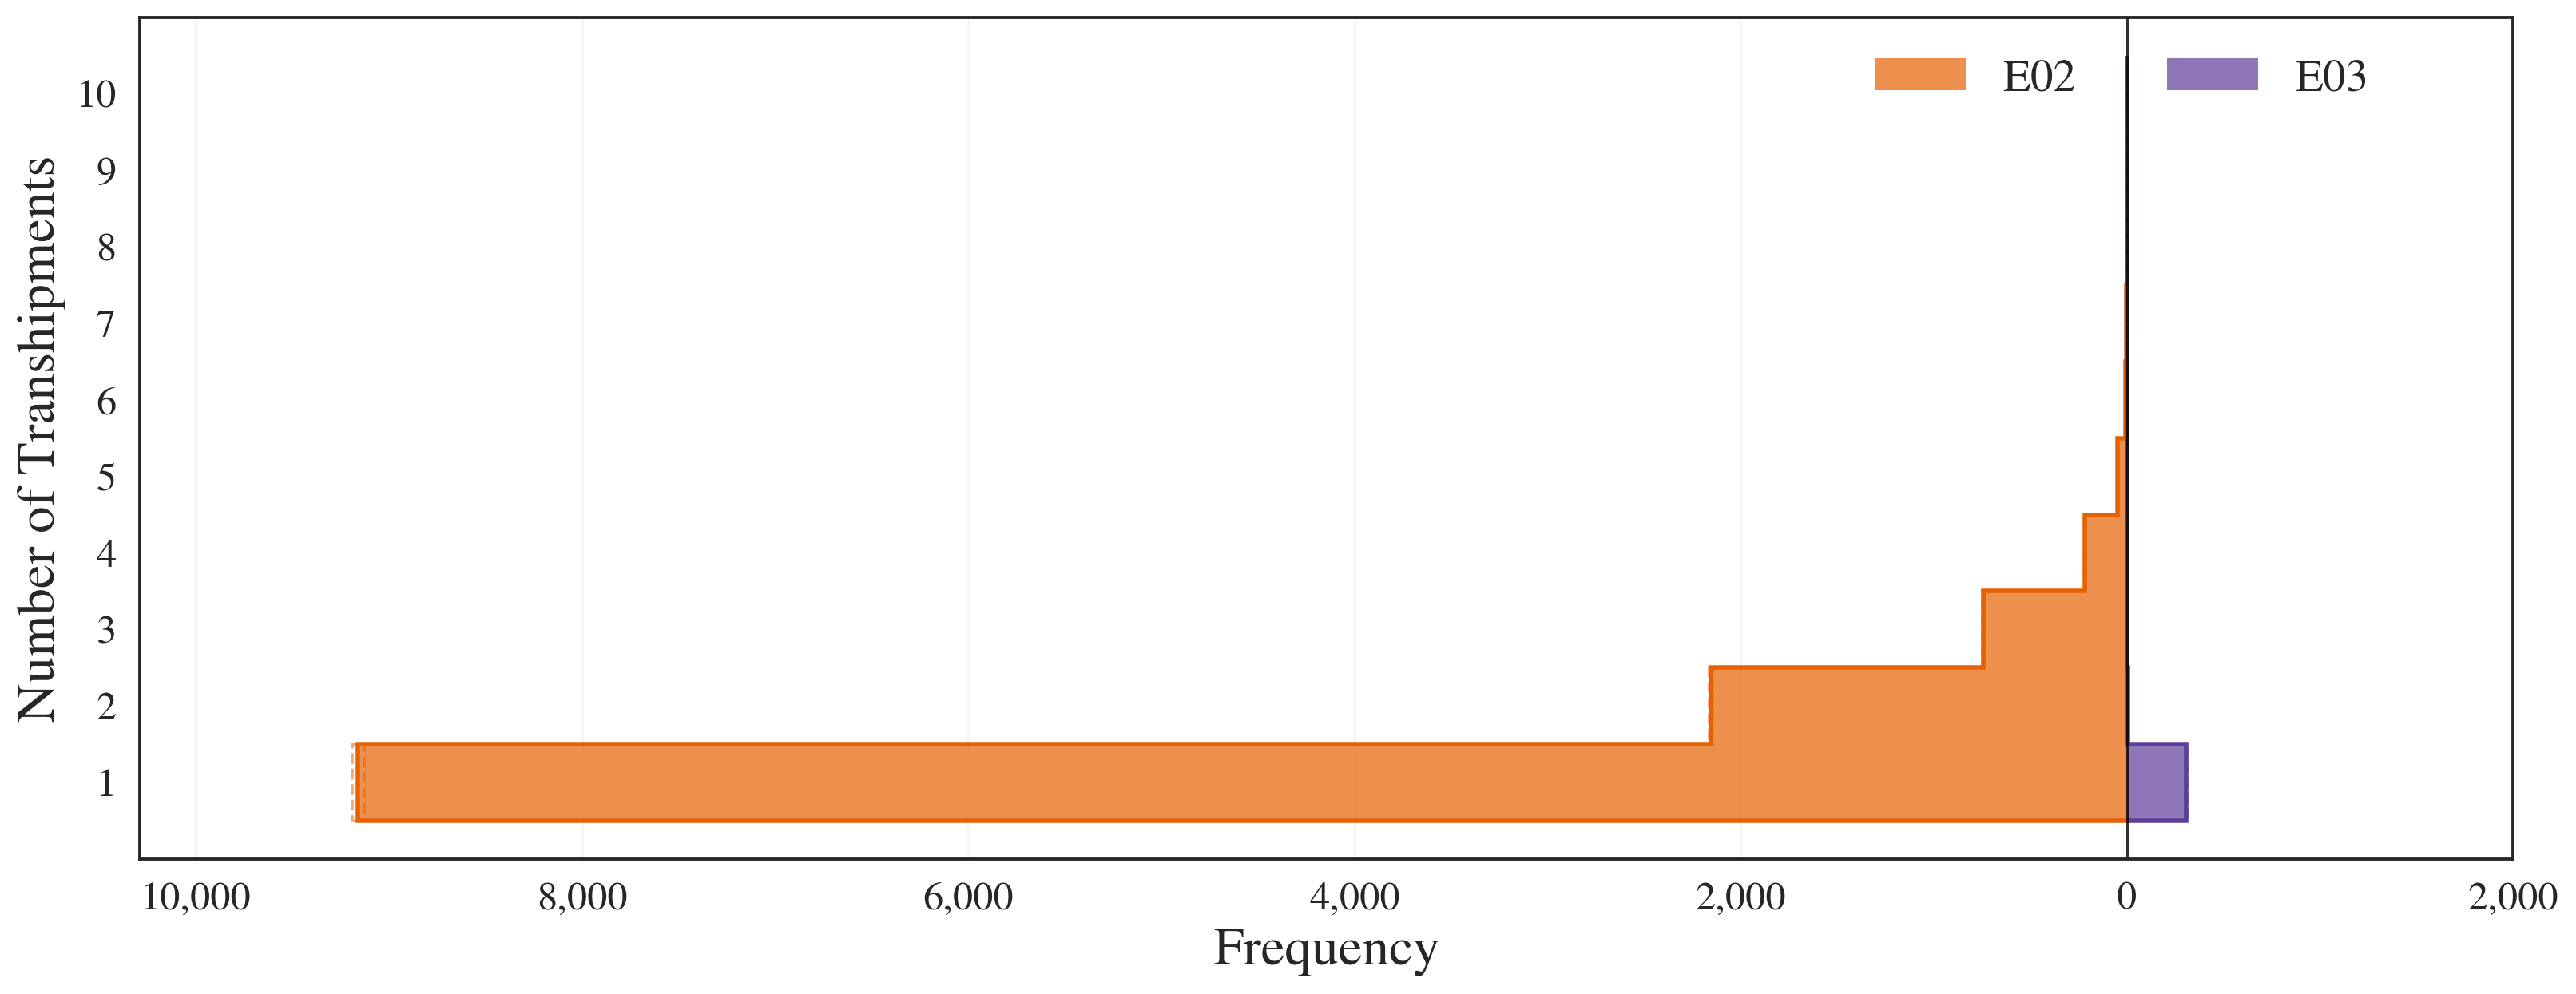

(<Figure size 3300x1320 with 1 Axes>,
 <Axes: xlabel='Frequency', ylabel='Number of Transhipments'>)

In [32]:
cf.plot_transfer_stairs_pyramid(
    shus_zero_transportation,
    shus_transportation_penalty,
    warmup=warmup_period,
    label_left='E02',
    label_right='E03',
    move_reason=move_reasons["SCD"],
    shelf_life=11,
    figsize=(15, 6),
    title=None,
    pdf="scratch/figures/Hermes/E02-E03-dist-multiple-moves-scd-pyramid.pdf",
    fontsize=22,
    ylim=(-0.0, 11),
    
)

### Age of units when moved

In [33]:
print('Skipping age of units when moved for SCD for SHUs with zero transportation penalty...\nUncomment the following code block to plot if desired.\n')
# cf.plot_age_of_units_when_moved(shus_zero_transportation, id_shu_dict,
#                                 figsize=(15, 15),
#                                 title=f'{scenario_labels["shus_zero_transportation"]} - Age of Units When Moved for SCD',
#                                 warmup=warmup_period, shelf_life=shelf_life, move_reason=move_reasons['SCD'],
#                                 )

Skipping age of units when moved for SCD for SHUs with zero transportation penalty...
Uncomment the following code block to plot if desired.



In [34]:
print('Skipping age of units when moved for SCD for SHUs with transportation penalty...\nUncomment the following code block to plot if desired.\n')
# cf.plot_age_of_units_when_moved(shus_transportation_penalty, id_shu_dict,
#                            figsize=(15, 15),
#                            title=f'{scenario_labels["shus_transportation_penalty"]} - Age of Units When Moved for SCD',
#                            warmup=warmup_period, shelf_life=shelf_life, move_reason=move_reasons['SCD'],
#                            )

Skipping age of units when moved for SCD for SHUs with transportation penalty...
Uncomment the following code block to plot if desired.



In [35]:
print('Skipping age of units when moved for rebalancing for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for k, v in all_results.items():
#     cf.plot_age_of_units_when_moved(v, id_shu_dict,
#                                 figsize=(15, 15),
#                                 title=f'{scenario_labels[k]} - Age of Units When Moved for Rebalancing',
#                                 warmup=warmup_period, shelf_life=shelf_life, move_reason=move_reasons['rebalancing'],
#                                 )

Skipping age of units when moved for rebalancing for all base scenarios...
Uncomment the following code block to plot if desired.



## Age Distributions

Plot the age distribution of inventory.

I don't think any of this is interesting...?

The stock is slightly skewed to the Colindale region because there are R0 units sent to Tooting from Manchester and Filton and no counterbalancing regular flow back to those regions.
This means supply in Colindale region (i.e., Colindale, Tooting, Cambridge, and Basilon) is slightly higher than demand, leading to slightly older stock in those SHUs and in the Colindale region overall.
Depending on the strictness of the transportation penalty and/or constraints, we can see in the non-Colindale regions that there are bumps/larger tails (to varying extents) in the age distribution when older stock is moved in from Colindale region SHUs to meet demand in those regions.

In [36]:
print('Skipping age distribution of units overall for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for k, v in all_results.items():    
#     print(f"All ages mean for {scenario_labels_compact[k]}:")
#     _dft = cf.plot_age_dist_blood(v, 'total_age_dist',
#                         age_range=np.arange(0, shelf_life + 1), vmax=None, days_range=np.arange(days_range_start, days_range_end),
#                         re_index=True,
#                         print_max=True,
#                         title=f'{scenario_labels_compact[k]} - Age Distribution of Blood Units',
#                         # title='L01: Age Distribution of Blood Units',
#                         #   title='E01: Age Distribution of Blood Units',
#                         #   title='E02: Age Distribution of Blood Units',
#                         #   title='E03: Age Distribution of Blood Units',
#                         cmap='binary', plot_avg=True, print_mean=True,
#                         figsize=(7, 3.5),
#                         dpi=120,
#                         #    pdf='scratch/figures/Enlil/age_dist_rbcs_no_maj.pdf',
#                         )

Skipping age distribution of units overall for all base scenarios...
Uncomment the following code block to plot if desired.



In [37]:
print('Skipping age distribution of units at each location for all base scenarios...\nUncomment the following code block to plot if desired.\n')
# for key, value in all_results.items():
#     cf.plot_age_distributions_locations(value,
#                                         age_range=age_range,
#                                         days_range=np.arange(warmup_period, time_horizon) + 1,
#                                         figsize=(12, 18), dpi=200,
#                                         pdf=None,
#                                         title=scenario_labels[key],
#                                         shelf_life=shelf_life,
#                                         time_horizon=time_horizon,
#                                         error_over_days=True,
#                                         )

Skipping age distribution of units at each location for all base scenarios...
Uncomment the following code block to plot if desired.



In [38]:
num_expiries_in_transit, all_expiries = cf.how_many_expiries_during_transit(limited_siloed_shus,
                                                              time_horizon=time_horizon,)
print(f'Number of expiries in transit in Limited Siloed SHUs: {num_expiries_in_transit}. Number of all expiries: {all_expiries}.')
num_expiries_in_transit, all_expiries = cf.how_many_expiries_during_transit(siloed_shus,
                                                              time_horizon=time_horizon,)
print(f'Number of expiries in transit in Siloed SHUs: {num_expiries_in_transit}. Number of all expiries: {all_expiries}.')
num_expiries_in_transit, all_expiries = cf.how_many_expiries_during_transit(shus_zero_transportation,
                                                              time_horizon=time_horizon,)
print(f'Number of expiries in transit in SHUs Zero Transportation: {num_expiries_in_transit}. Number of all expiries: {all_expiries}.')
num_expiries_in_transit, all_expiries = cf.how_many_expiries_during_transit(shus_transportation_penalty,
                                                              time_horizon=time_horizon,)
print(f'Number of expiries in transit in SHUs Transportation Penalty: {num_expiries_in_transit}. Number of all expiries: {all_expiries}.')

Number of expiries in transit in Limited Siloed SHUs: 0.0. Number of all expiries: 0.0.
Number of expiries in transit in Siloed SHUs: 0.0. Number of all expiries: 0.0.
Number of expiries in transit in SHUs Zero Transportation: 0.0. Number of all expiries: 0.03.
Number of expiries in transit in SHUs Transportation Penalty: 0.0. Number of all expiries: 0.0.


## Variation in Transportation Penalties

What is the trade-off between alloimmunisation and SCD moves as we vary the transportation penalties?

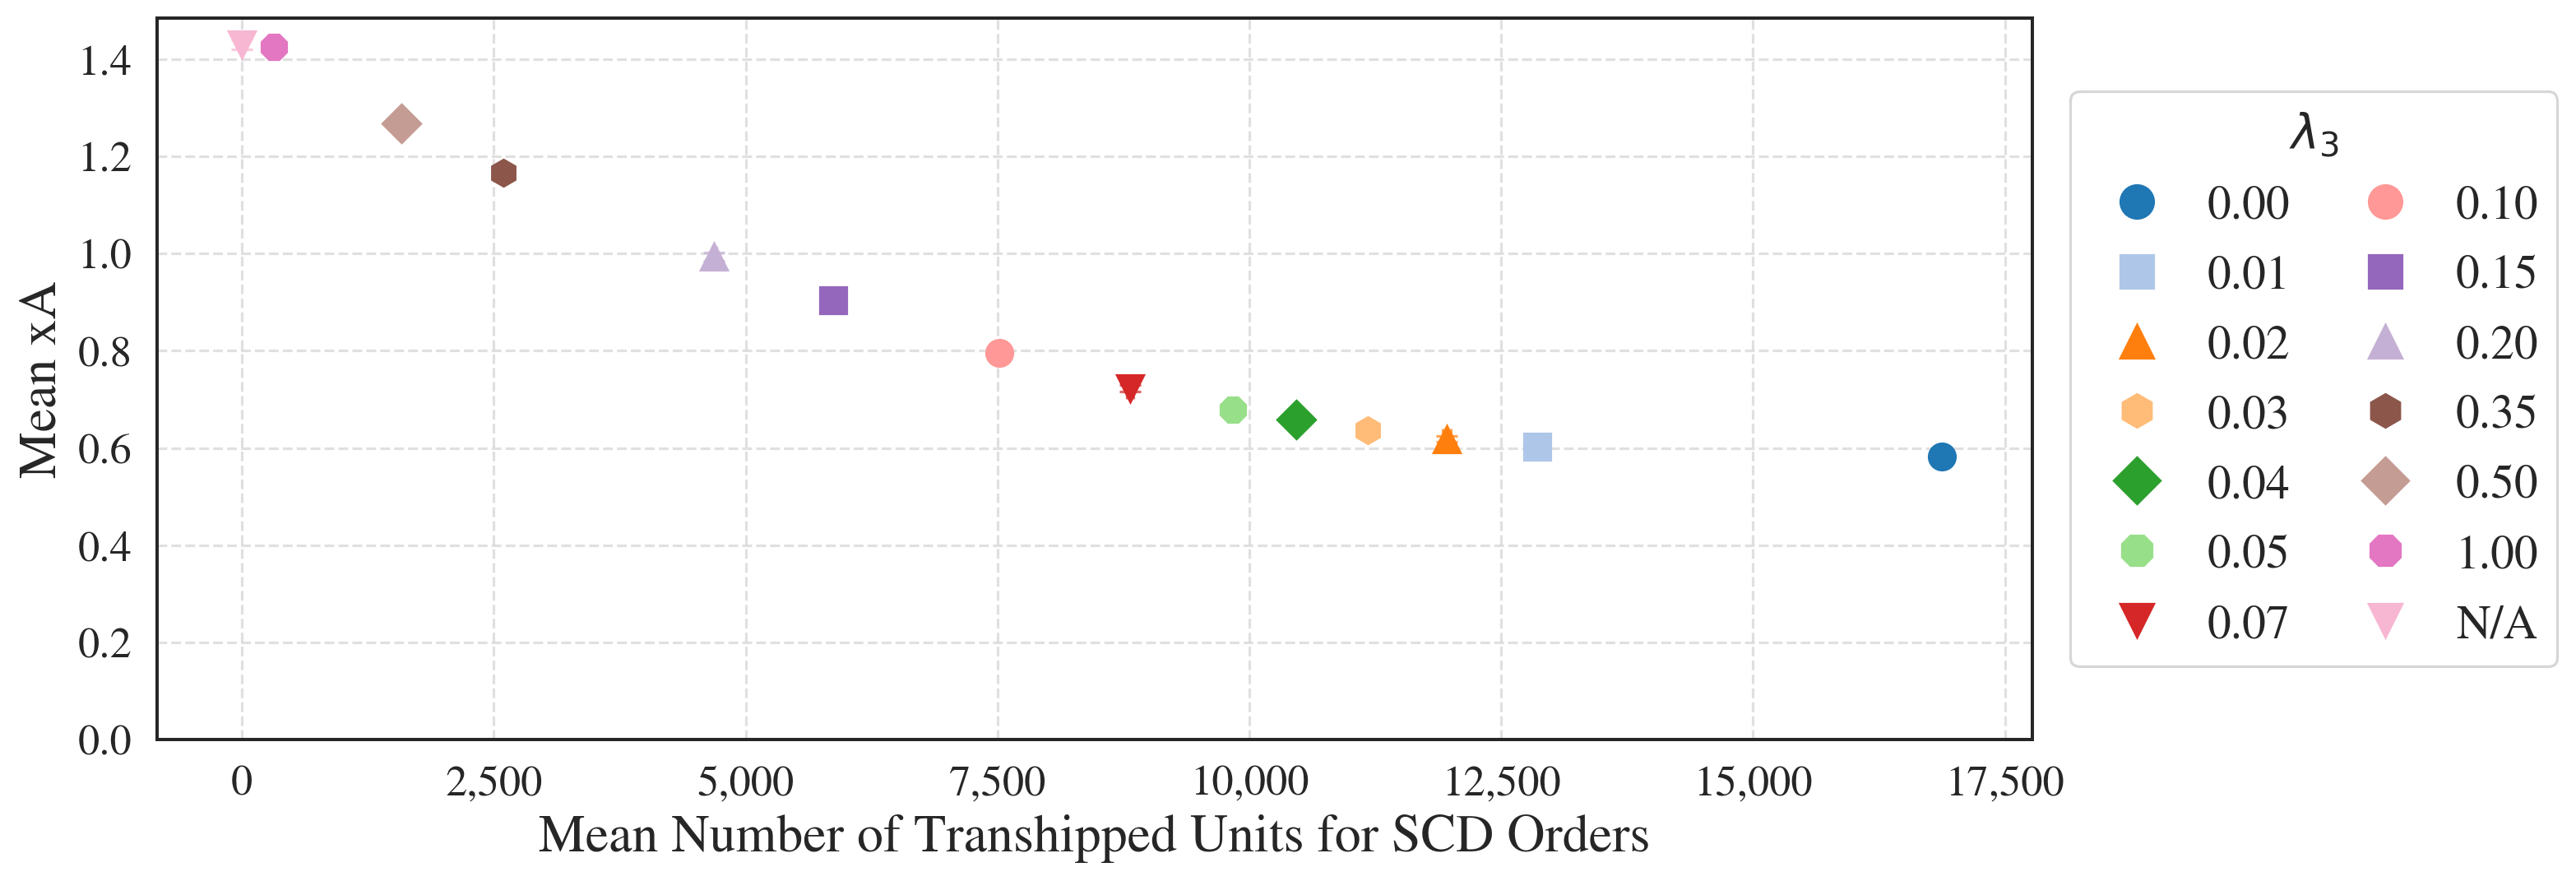

In [43]:
cf.plot_objective_means_pareto(list(all_transport_weight_results.values()),
                               labels=list(transport_weight_labels.values()),
                               dpi=230, figsize=(18, 5), # label_points=True,
                               legend_ncol=2, legend_fontsize=18,
                               fontsize=20,
                               palette='tab20',
                               use_marker_variation=True,
                               marker_cycle=('o', 's', '^', 'h', 'D', '8', 'v', ),
                               marker_size=10,
                               palette_offset=0,
                               marker_offset=0,
                               pdf='scratch/figures/Hermes/scd_moves-vs-alloimmunisation-tradeoff.pdf',
)

In [44]:
# to_exclude = ['transport_weight_2_00', 'transport_weight_5_00', 'transport_weight_10',
#               'transport_weight_50', 'transport_weight_100',
#               'transport_weight_100', 'transport_weight_1e3',
#               'transport_weight_1e4', 'transport_weight_1e5',
#               'transport_weight_1e6',]
# cf.plot_objective_means_pareto([v for k, v in all_transport_weight_results.items() if k not in to_exclude],
#                                labels=[v for k, v in transport_weight_labels.items() if k not in to_exclude],
#                                dpi=200,
# )

In [45]:
cf.objectives_stats_table(all_transport_weight_results)

,transport_weight_0_00,transport_weight_0_01,transport_weight_0_02,transport_weight_0_03,transport_weight_0_04,transport_weight_0_05,transport_weight_0_07,transport_weight_0_10,transport_weight_0_15,transport_weight_0_20,transport_weight_0_35,transport_weight_0_50,transport_weight_1_00,transport_weight_inf
alloimmunisations,0.583 ± 0.006,0.602 ± 0.006,0.618 ± 0.006,0.637 ± 0.006,0.658 ± 0.006,0.678 ± 0.007,0.722 ± 0.007,0.796 ± 0.008,0.903 ± 0.009,0.994 ± 0.009,1.166 ± 0.009,1.267 ± 0.009,1.425 ± 0.010,1.431 ± 0.010
scd_shortages,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.060 ± 0.060,0.220 ± 0.114
expiries,0.030 ± 0.022,0.010 ± 0.010,0.020 ± 0.014,0.020 ± 0.020,0.020 ± 0.014,0.010 ± 0.010,0.000 ± 0.000,0.010 ± 0.010,0.000 ± 0.000,0.010 ± 0.010,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
all_shortages,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.690 ± 0.606,0.220 ± 0.114
moves,20835.780 ± 133.983,16784.840 ± 124.098,15775.890 ± 116.306,14927.320 ± 110.971,14115.720 ± 112.690,13518.250 ± 109.772,12430.360 ± 111.195,11005.420 ± 112.634,9210.400 ± 106.419,7918.530 ± 100.781,5675.250 ± 95.083,4518.350 ± 81.443,3458.160 ± 91.019,2529.620 ± 55.523
scd_moves,16876.240 ± 53.598,12854.230 ± 44.167,11958.550 ± 39.554,11174.140 ± 36.832,10462.580 ± 35.839,9837.720 ± 34.108,8817.700 ± 31.650,7515.900 ± 29.091,5871.340 ± 25.711,4686.780 ± 21.941,2597.560 ± 20.769,1585.670 ± 15.647,319.360 ± 6.586,0.000 ± 0.000
other_moves,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
O_neg_level,0.141 ± 0.000,0.141 ± 0.000,0.141 ± 0.000,0.141 ± 0.000,0.141 ± 0.000,0.140 ± 0.000,0.140 ± 0.000,0.140 ± 0.000,0.139 ± 0.000,0.139 ± 0.000,0.138 ± 0.000,0.138 ± 0.000,0.137 ± 0.000,0.137 ± 0.000
O_pos_level,0.356 ± 0.000,0.356 ± 0.000,0.356 ± 0.000,0.356 ± 0.000,0.357 ± 0.000,0.357 ± 0.000,0.357 ± 0.000,0.357 ± 0.000,0.357 ± 0.000,0.356 ± 0.000,0.356 ± 0.000,0.356 ± 0.000,0.355 ± 0.000,0.355 ± 0.000
O_level,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.497 ± 0.000,0.496 ± 0.000,0.495 ± 0.000,0.494 ± 0.000,0.494 ± 0.000,0.493 ± 0.000,0.492 ± 0.000


In [46]:
moves_distr_mean = {}
moves_distr_stderr = {}
for scenario in all_transport_weight_results.keys():
    if scenario == 'transport_weight_inf':
        continue
    result = cf.distribution_multiple_moves(all_transport_weight_results[scenario], plot_graph=False, return_hist=True,
                                                warmup=warmup_period, move_reason=move_reasons['SCD'], shelf_life=shelf_life,)
    moves_distr_mean[scenario] = result[0]
    moves_distr_stderr[scenario] = result[1]
df = pd.DataFrame(moves_distr_mean, index=np.arange(0, shelf_life),)
df.rename(columns={scenario: scenario.replace('transport_weight_', 'TW=').replace('_', '.') for scenario in all_transport_weight_results.keys()}, inplace=True)
df_stderr = pd.DataFrame(moves_distr_stderr, index=np.arange(0, shelf_life),)
df_stderr.rename(columns={scenario: scenario.replace('transport_weight_', 'TW=').replace('_', '.') for scenario in all_transport_weight_results.keys()}, inplace=True)
df_new = pd.DataFrame(np.char.add(
        np.char.add(np.char.mod('%.0f', df.to_numpy()), ' ± '),
        np.char.mod('%.2f', df_stderr.to_numpy())),
    index=df.index, columns=df.columns)

In [47]:
df_new.drop(index=0,)

,TW=0.00,TW=0.01,TW=0.02,TW=0.03,TW=0.04,TW=0.05,TW=0.07,TW=0.10,TW=0.15,TW=0.20,TW=0.35,TW=0.50,TW=1.00
1,9159 ± 29.66,8376 ± 26.97,8071 ± 26.82,7750 ± 24.32,7431 ± 23.97,7150 ± 25.28,6592 ± 22.56,5814 ± 19.77,4721 ± 19.42,3892 ± 16.56,2298 ± 17.03,1454 ± 13.67,308 ± 6.19
2,2154 ± 8.90,1513 ± 7.93,1368 ± 7.43,1242 ± 7.77,1131 ± 7.23,1034 ± 6.78,889 ± 7.26,711 ± 6.52,508 ± 6.38,364 ± 4.92,144 ± 3.06,65 ± 2.07,5 ± 0.41
3,743 ± 5.04,377 ± 4.40,312 ± 3.65,264 ± 3.08,221 ± 2.68,182 ± 2.67,135 ± 2.07,87 ± 1.55,44 ± 1.12,22 ± 0.68,4 ± 0.29,1 ± 0.11,0 ± 0.00
4,217 ± 2.93,68 ± 1.39,47 ± 0.91,33 ± 0.77,24 ± 0.70,17 ± 0.54,10 ± 0.43,5 ± 0.27,1 ± 0.12,0 ± 0.07,0 ± 0.00,0 ± 0.00,0 ± 0.00
5,49 ± 1.13,9 ± 0.39,5 ± 0.26,3 ± 0.19,2 ± 0.16,1 ± 0.08,0 ± 0.06,0 ± 0.04,0 ± 0.01,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00
6,9 ± 0.39,1 ± 0.11,0 ± 0.06,0 ± 0.04,0 ± 0.03,0 ± 0.02,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00
7,1 ± 0.16,0 ± 0.02,0 ± 0.01,0 ± 0.01,0 ± 0.01,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00
8,0 ± 0.05,0 ± 0.01,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00
9,0 ± 0.01,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00
10,0 ± 0.01,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00,0 ± 0.00


### Distribution of the Number of Transfers each Day

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


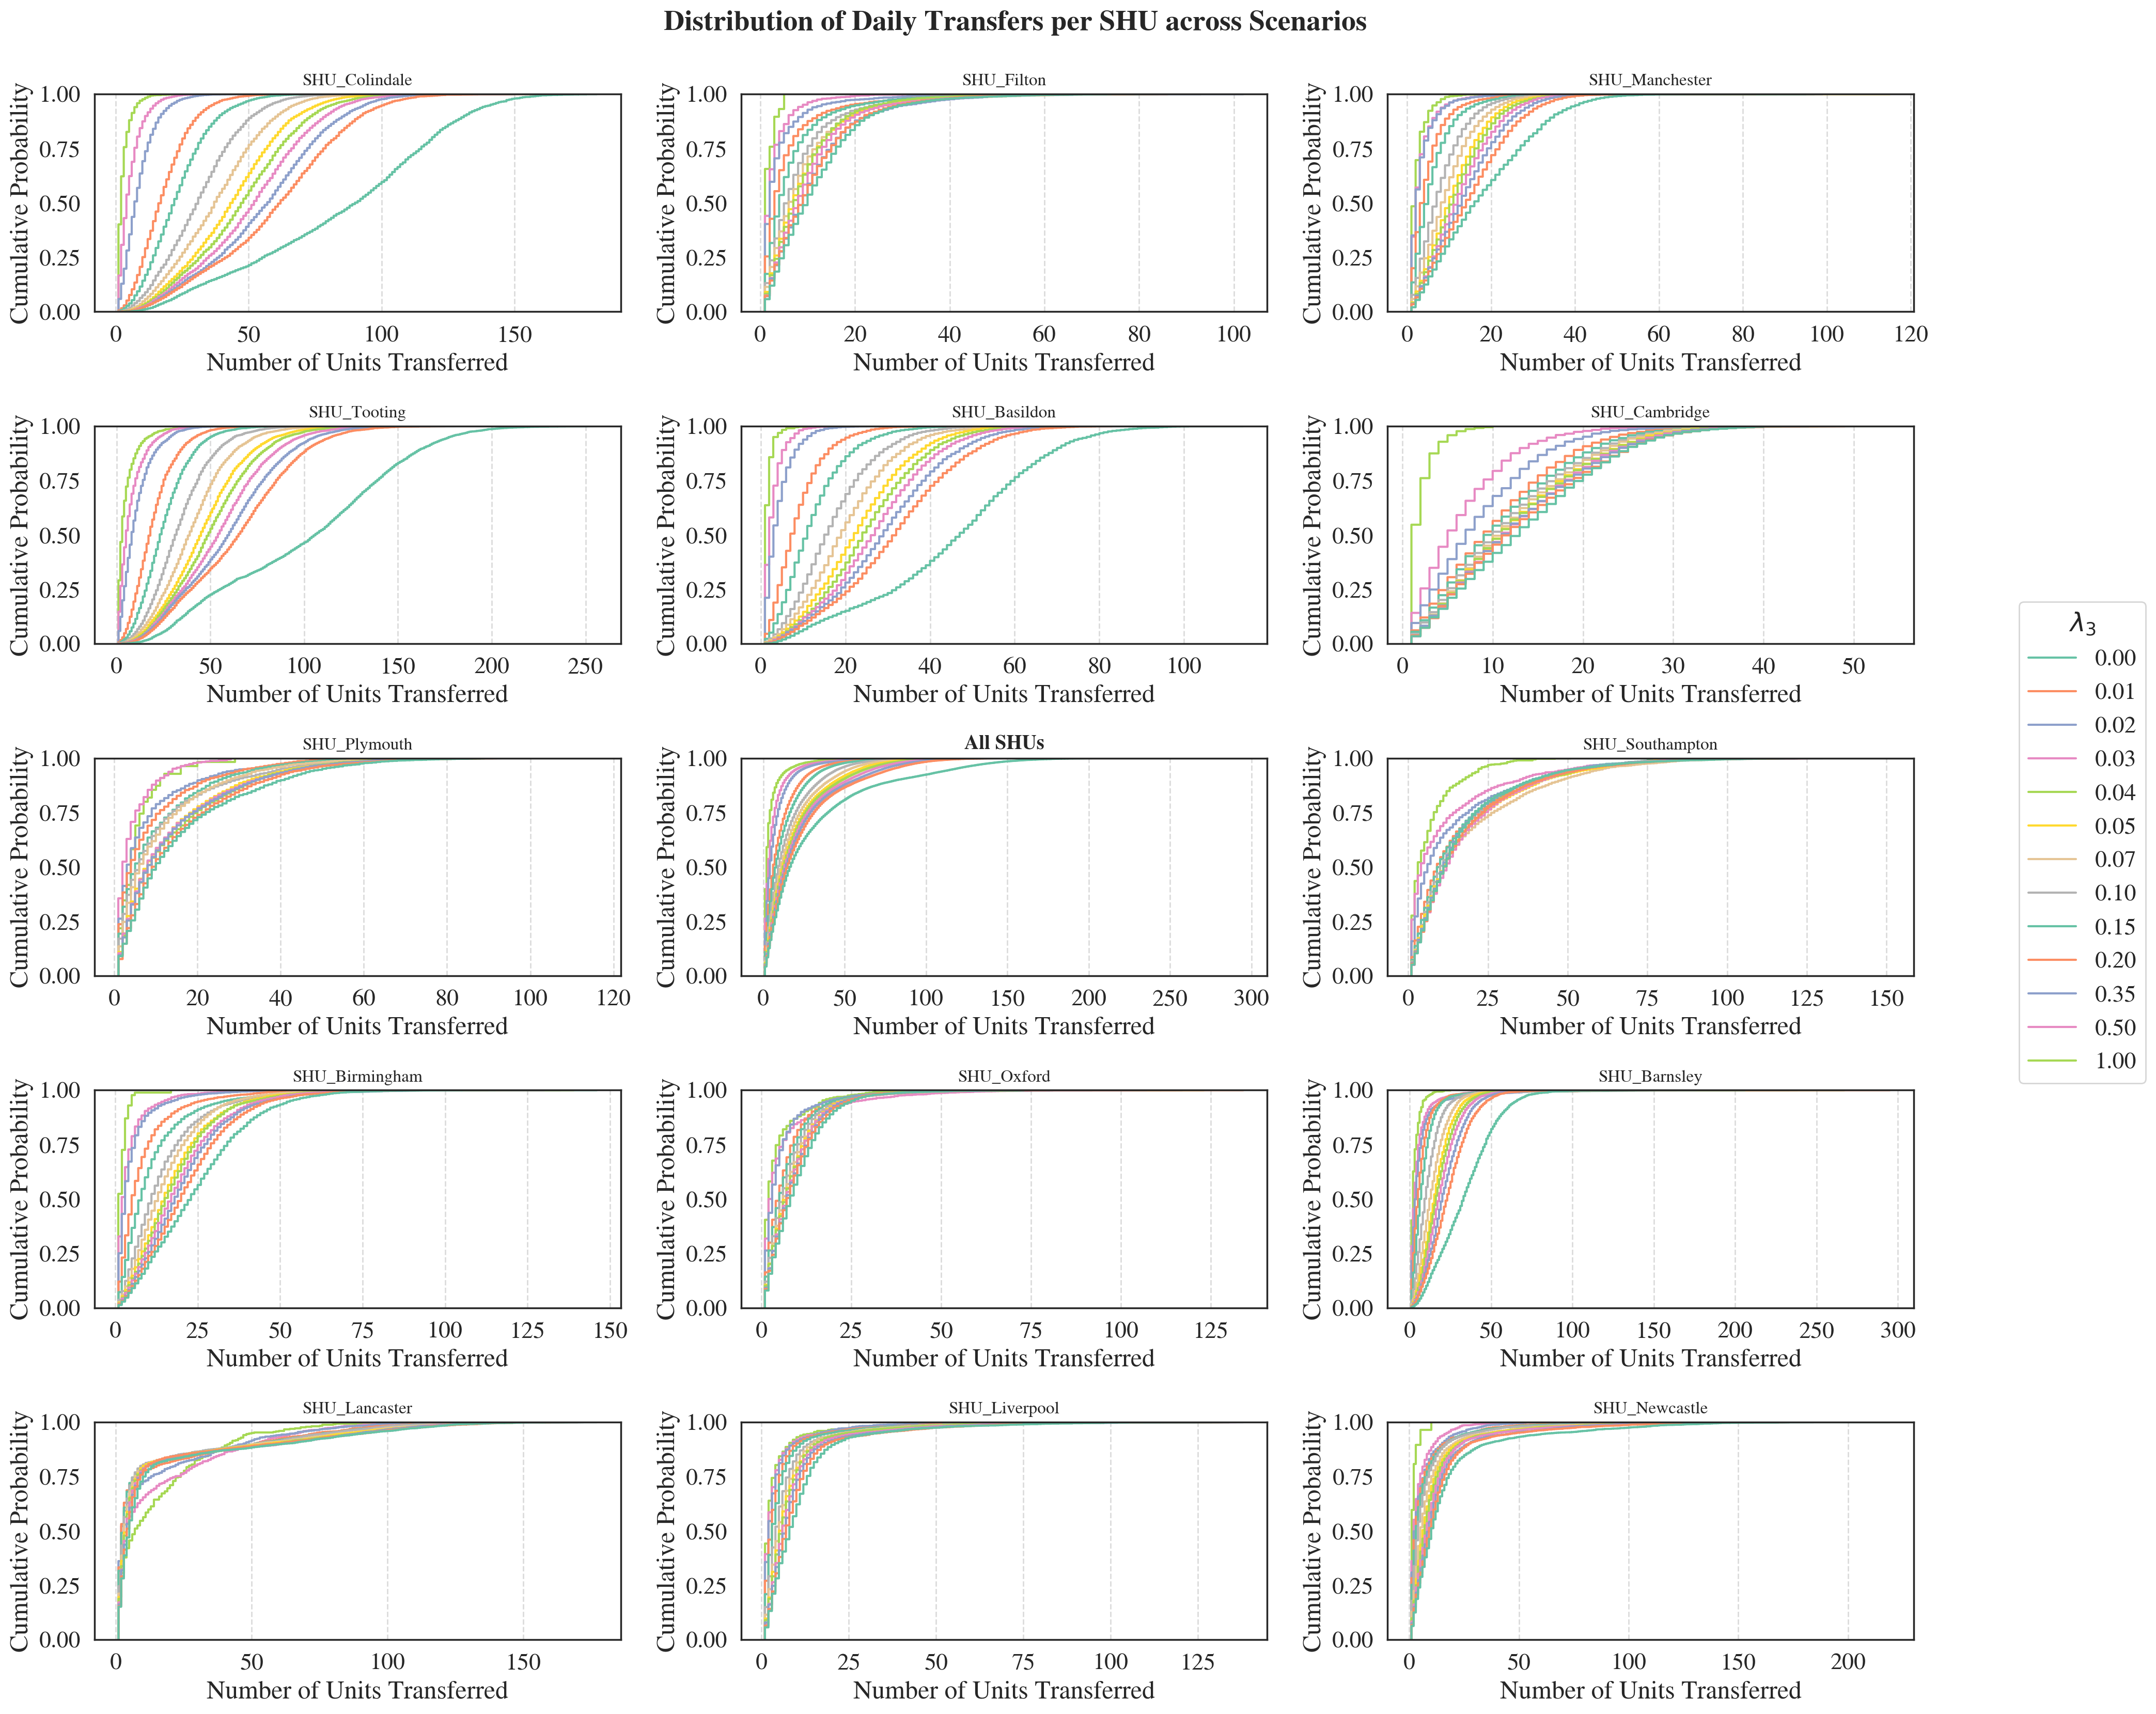

In [48]:
to_exclude = []
cf.plot_dist_moves_per_day({k: v for k, v in all_transport_weight_results.items() if k not in to_exclude},
                           id_shu_dict, warm_up=warmup_period, move_reason=move_reasons['SCD'],
                           file_labels={k: v for k, v in transport_weight_labels.items() if k not in to_exclude},
                           dpi=200, legend_title='$\lambda_3$',
                           figsize=(20, 17),  # fig size for one plot with subplots
                        #    separate_plots=True, figsize=(7,5),  # fig size for multiple individual plots
                           plot_type='cdf')
del to_exclude

In [49]:
# to_exclude = []
# dashboard = cf.dist_moves_per_day_dashboard({k: v for k, v in all_transport_weight_results.items() if k not in to_exclude},
#                            id_shu_dict, warm_up=warmup_period, move_reason=move_reasons['SCD'],
#                            file_labels={k: v for k, v in transport_weight_labels.items() if k not in to_exclude},
# )
# del to_exclude

In [50]:
# display(dashboard)

### Transfer Matrices

In [51]:
# scd_transpo_mats = cf.plot_moves_matrix([transport_weight_0_00, transport_weight_0_01, transport_weight_0_02,
#                                          transport_weight_0_05, transport_weight_0_10, transport_weight_0_20,
#                                          transport_weight_0_50, transport_weight_1_00,],
#                      titles=['$\\lambda_3$ = 0.00 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.01 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.02 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.05 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.10 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.20 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 0.50 - Weekly Transfers for SCD Requests',
#                               '$\\lambda_3$ = 1.00 - Weekly Transfers for SCD Requests',],
#                      moves_reason='SCD',
#                      order_of_shus=order_of_locations, return_matrices=True,
#                      data_divisor=6,)


## Scratchpad

In [52]:
to_exclude = []
moves_dist_df = cf.moves_per_day_df({k: v for k, v in all_transport_weight_results.items() if k not in to_exclude},
                           id_shu_dict, warm_up=warmup_period, time_horizon=time_horizon, keep_zero_days=True,
                           move_reason=move_reasons['SCD'],
                           file_labels={k: v for k, v in transport_weight_labels.items() if k not in to_exclude},
                           # out_file='scratch/moves_per_day_transport_weight_comparison.tsv',
)

In [53]:
# Remove "SHU_" prefix from shu column values
moves_dist_df['shu'] = moves_dist_df['shu'].str.replace(r'^SHU_', '', regex=True)

# Optional quick check
moves_dist_df['shu'].head()

0    Colindale
1    Colindale
2    Colindale
3    Colindale
4    Colindale
Name: shu, dtype: object

In [ ]:
moves_dist_df

In [53]:
np.savez_compressed('scratch/data_files/output/moves_per_day_transport_weight_comparison.npz',
                    moves_dist_df=moves_dist_df.to_numpy(),
                    columns=list(moves_dist_df.columns),)